# Прогноз дождя в Австралии

Исследуется задача бинарной классификации `RainTomorrow`.

## Гипотезы

1. Класс `RainTomorrow=Yes` встречается заметно реже, поэтому одной accuracy недостаточно.
2. Вероятность дождя зависит от сезона и метеостанции.
3. Добавление отдельного признака нулевых осадков улучшит `Rainfall_log1p`.
4. Из-за корреляции `TempRange` и `TempChange` один из них можно убрать без потери PR-AUC более 0.005.
5. `Evaporation` можно удалить без заметной потери качества, но удаление `Sunshine` и `Cloud3pm` ухудшит результат.
6. Регуляризованная логистическая регрессия будет устойчивее и качественнее одиночного дерева.
7. При большой глубине дерево начнёт переобучаться, а L1-отбор не ухудшит качество более чем на 0.005.

## 1. Загрузка данных

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
sns.set_theme(style="whitegrid", context="notebook")

DATA_PATH = Path("weatherAUS.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        "Положите weatherAUS.csv в одну папку с ноутбуком."
    )

df = pd.read_csv(DATA_PATH)
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

df.shape

(145460, 23)

In [2]:
display(df.head())
df.info()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,WNW,20.0,24.0,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,WSW,4.0,22.0,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,WSW,19.0,26.0,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,E,11.0,9.0,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,NW,7.0,20.0,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   Date           145460 non-null  datetime64[ns]
 1   Location       145460 non-null  object        
 2   MinTemp        143975 non-null  float64       
 3   MaxTemp        144199 non-null  float64       
 4   Rainfall       142199 non-null  float64       
 5   Evaporation    82670 non-null   float64       
 6   Sunshine       75625 non-null   float64       
 7   WindGustDir    135134 non-null  object        
 8   WindGustSpeed  135197 non-null  float64       
 9   WindDir9am     134894 non-null  object        
 10  WindDir3pm     141232 non-null  object        
 11  WindSpeed9am   143693 non-null  float64       
 12  WindSpeed3pm   142398 non-null  float64       
 13  Humidity9am    142806 non-null  float64       
 14  Humidity3pm    140953 non-null  float64       
 15  

In [3]:
print("Период:", df["Date"].min(), "—", df["Date"].max())
print("Метеостанций:", df["Location"].nunique())
print("Полных дубликатов:", df.duplicated().sum())
print(
    "Дубликатов Date + Location:",
    df.duplicated(subset=["Date", "Location"]).sum()
)

Период: 2007-11-01 00:00:00 — 2017-06-25 00:00:00
Метеостанций: 49
Полных дубликатов: 0
Дубликатов Date + Location: 0


In [4]:
if df.duplicated().any():
    df = df.drop_duplicates().copy()

eda = df.dropna(subset=["RainTomorrow"]).copy()
eda["target"] = eda["RainTomorrow"].map({"No": 0, "Yes": 1})

print("Размер после удаления строк без цели:", eda.shape)

Размер после удаления строк без цели: (142193, 24)


## 2. Целевая переменная

,count,percent
RainTomorrow,,
No,110316,77.58
Yes,31877,22.42


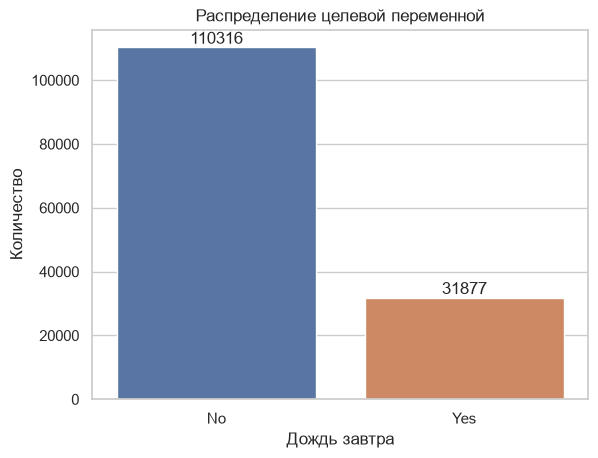

In [5]:
target_stats = pd.DataFrame({
    "count": eda["RainTomorrow"].value_counts(),
    "percent": (
        eda["RainTomorrow"]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
    )
})

display(target_stats)

ax = sns.countplot(
    data=eda,
    x="RainTomorrow",
    hue="RainTomorrow",
    legend=False
)

ax.set_title("Распределение целевой переменной")
ax.set_xlabel("Дождь завтра")
ax.set_ylabel("Количество")

for container in ax.containers:
    ax.bar_label(container, fmt="%d")

plt.show()

**Вывод:** класс `Yes` составляет 22.42%, поэтому выборка умеренно несбалансирована.
Accuracy будет дополняться PR-AUC, ROC-AUC, F1, precision и recall.
PR-AUC случайной модели ожидается примерно на уровне доли положительного класса.

## 3. Пропуски

,missing_count,missing_percent,unique_values
Sunshine,67816,47.69,145
Evaporation,60843,42.79,356
Cloud3pm,57094,40.15,10
Cloud9am,53657,37.74,10
Pressure9am,14014,9.86,546
Pressure3pm,13981,9.83,549
WindDir9am,10013,7.04,16
WindGustDir,9330,6.56,16
WindGustSpeed,9270,6.52,67
WindDir3pm,3778,2.66,16


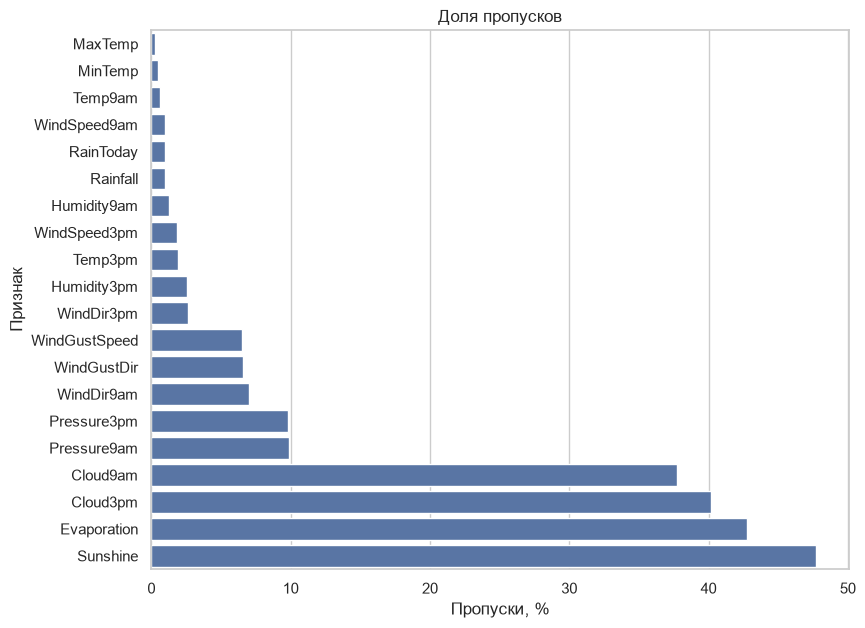

In [6]:
missing_report = pd.DataFrame({
    "missing_count": eda.isna().sum(),
    "missing_percent": eda.isna().mean().mul(100).round(2),
    "unique_values": eda.nunique()
}).sort_values("missing_percent", ascending=False)

display(missing_report.head(15))

missing_plot = (
    missing_report[missing_report["missing_percent"] > 0]
    .sort_values("missing_percent")
)

plt.figure(figsize=(9, 7))
sns.barplot(
    data=missing_plot.reset_index(),
    x="missing_percent",
    y="index"
)
plt.xlabel("Пропуски, %")
plt.ylabel("Признак")
plt.title("Доля пропусков")
plt.show()

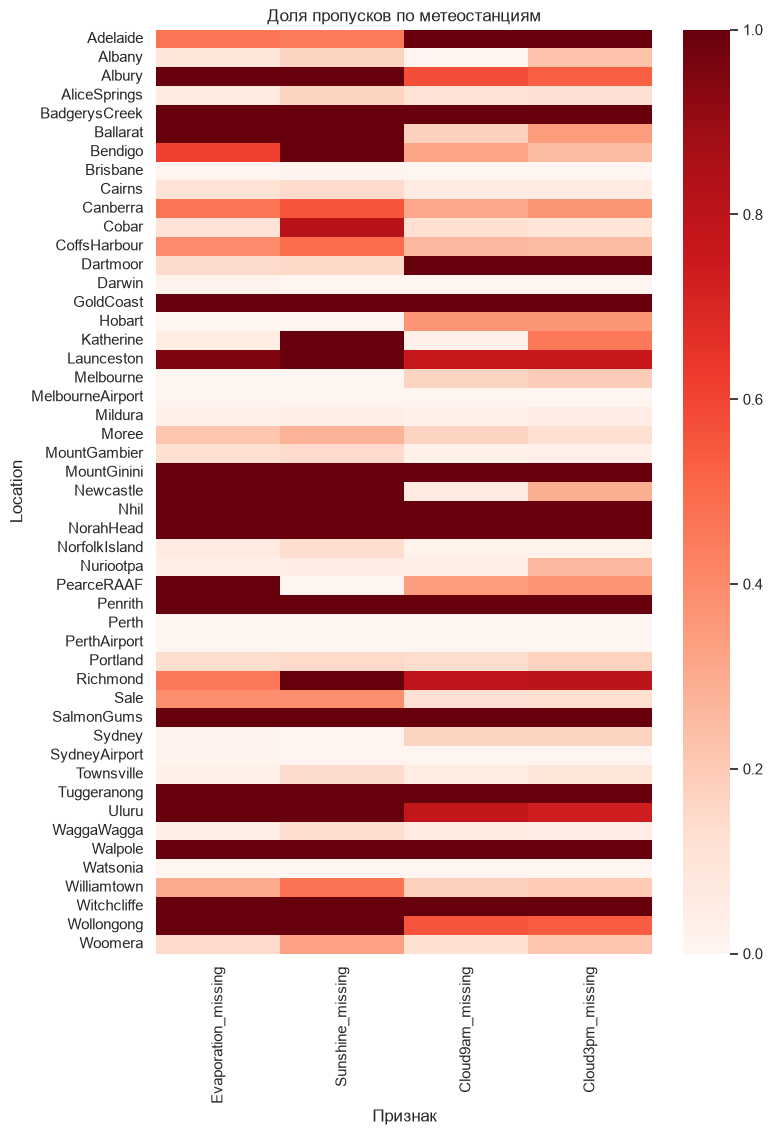

In [7]:
high_missing = ["Evaporation", "Sunshine", "Cloud9am", "Cloud3pm"]

missing_by_location = (
    eda.assign(**{
        f"{col}_missing": eda[col].isna()
        for col in high_missing
    })
    .groupby("Location")[
        [f"{col}_missing" for col in high_missing]
    ]
    .mean()
)

plt.figure(figsize=(8, 12))
sns.heatmap(
    missing_by_location,
    cmap="Reds",
    vmin=0,
    vmax=1
)
plt.title("Доля пропусков по метеостанциям")
plt.xlabel("Признак")
plt.ylabel("Location")
plt.show()

In [8]:
missing_target_rows = []

for col in high_missing:
    stats = (
        eda.assign(is_missing=eda[col].isna())
        .groupby("is_missing")["target"]
        .agg(["mean", "count"])
    )

    missing_target_rows.append({
        "feature": col,
        "rain_rate_present": stats.loc[False, "mean"],
        "rain_rate_missing": stats.loc[True, "mean"],
        "present_count": stats.loc[False, "count"],
        "missing_count": stats.loc[True, "count"]
    })

display(pd.DataFrame(missing_target_rows).round(3))

,feature,rain_rate_present,rain_rate_missing,present_count,missing_count
0,Evaporation,0.220,0.230,81350,60843
1,Sunshine,0.226,0.222,74377,67816
2,Cloud9am,0.233,0.210,88536,53657
3,Cloud3pm,0.238,0.203,85099,57094


**Вывод:** больше всего пропусков в `Sunshine` (47.69%), `Evaporation` (42.79%),
`Cloud3pm` (40.15%) и `Cloud9am` (37.74%). Их доля заметно зависит от метеостанции,
поэтому пропуски нельзя считать полностью случайными. Признаки не удаляю до сравнения моделей.

## 4. Распределения исходных числовых признаков

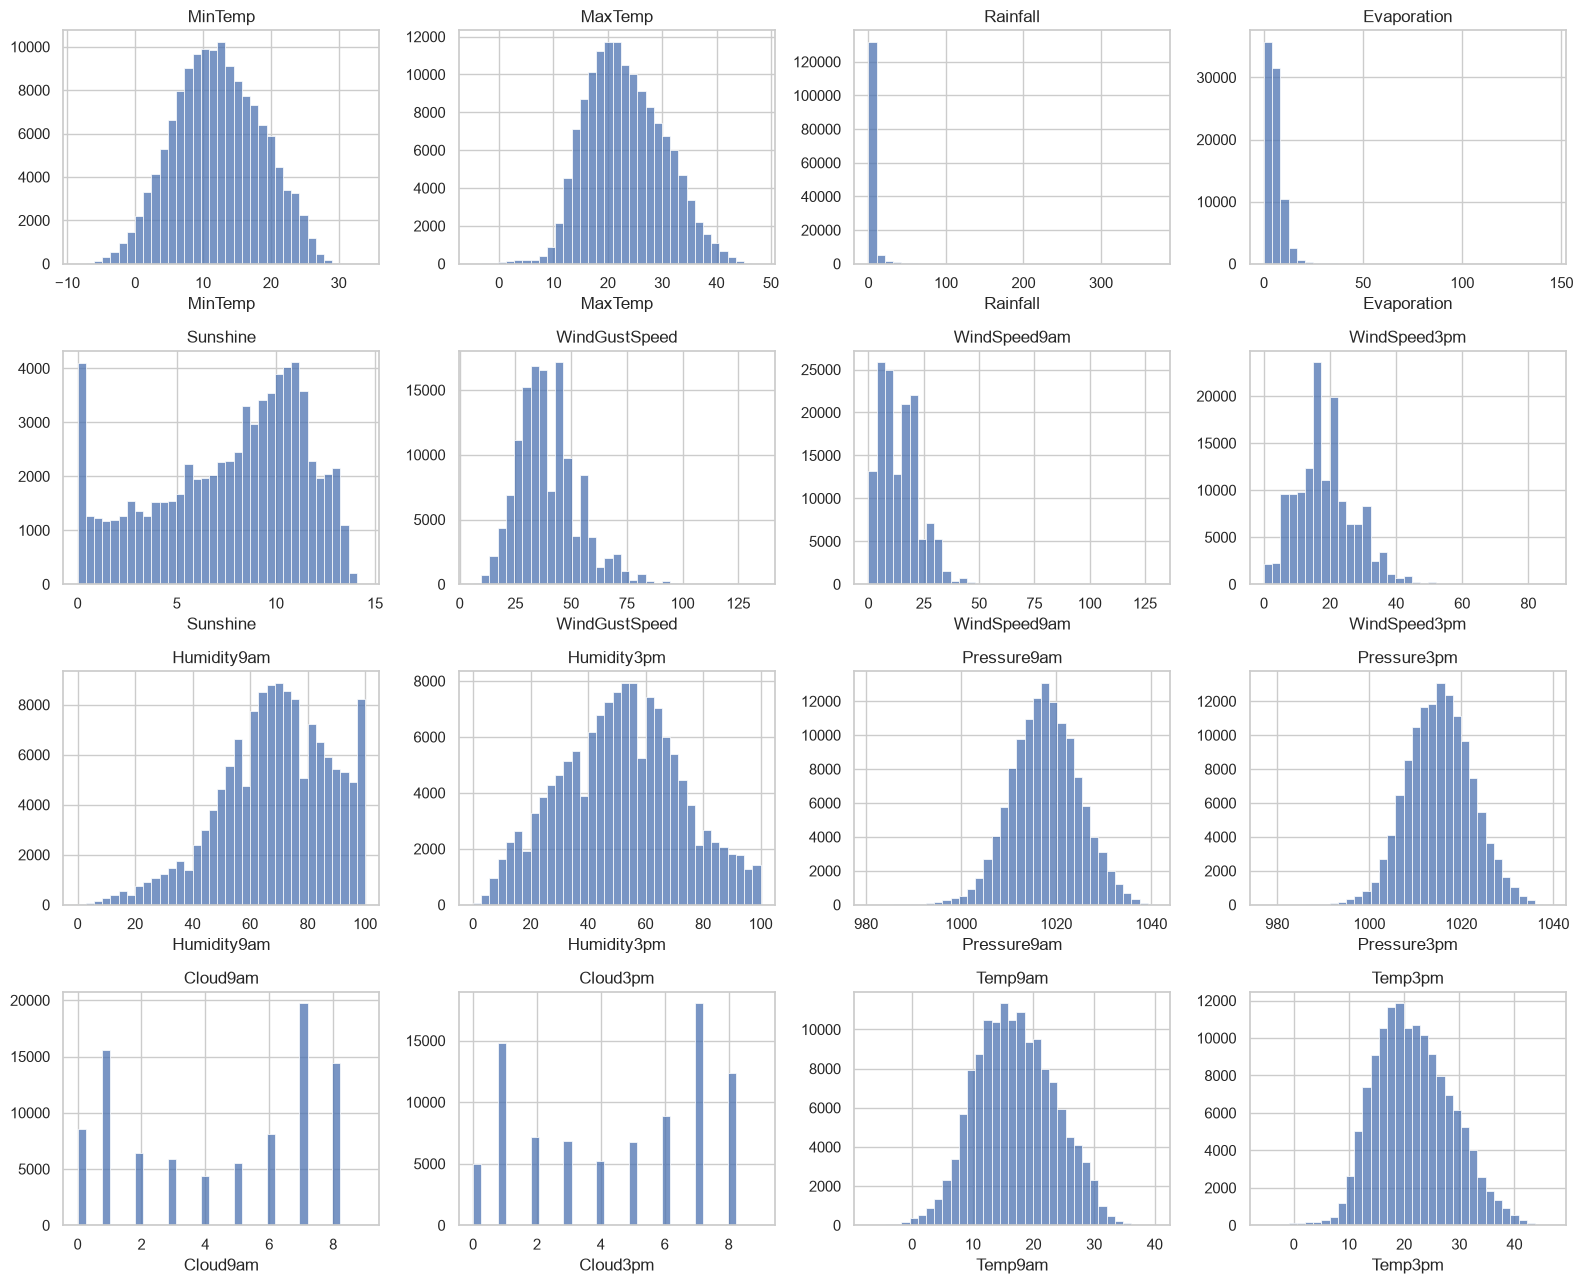

In [9]:
original_numeric = [
    "MinTemp", "MaxTemp", "Rainfall", "Evaporation", "Sunshine",
    "WindGustSpeed", "WindSpeed9am", "WindSpeed3pm",
    "Humidity9am", "Humidity3pm",
    "Pressure9am", "Pressure3pm",
    "Cloud9am", "Cloud3pm",
    "Temp9am", "Temp3pm"
]

fig, axes = plt.subplots(4, 4, figsize=(16, 13))
axes = axes.ravel()

for ax, col in zip(axes, original_numeric):
    sns.histplot(
        data=eda,
        x=col,
        bins=35,
        ax=ax
    )
    ax.set_title(col)
    ax.set_ylabel("")

plt.tight_layout()
plt.show()

**Вывод:** температурные признаки и давление имеют относительно гладкие распределения.
`Rainfall` и `Evaporation` сильно скошены вправо, поэтому для них проверяется `log1p`.
`Cloud9am` и `Cloud3pm` являются дискретными порядковыми признаками.

## 5. Корреляции до создания новых признаков

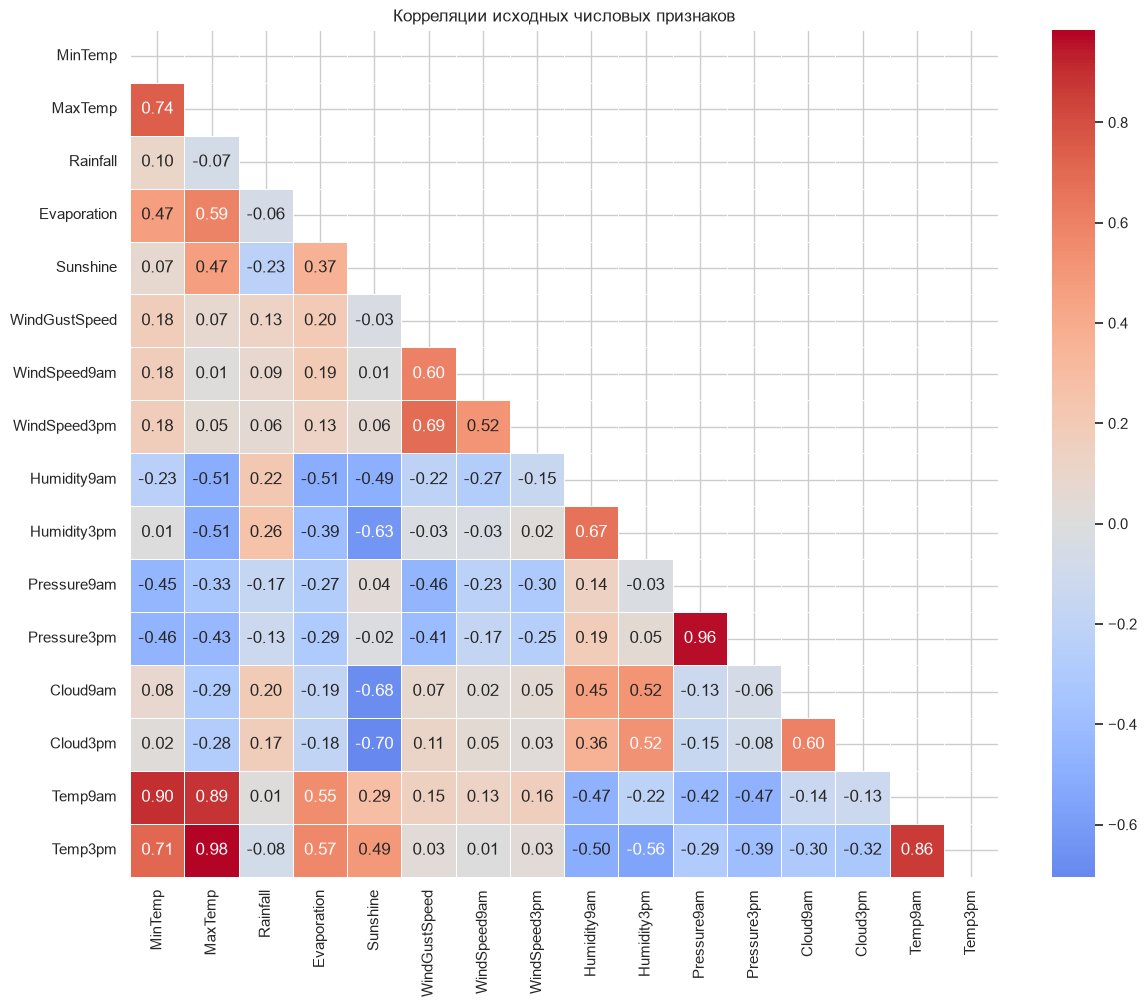

In [10]:
corr_before = eda[original_numeric].corr()

plt.figure(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_before, dtype=bool))

sns.heatmap(
    corr_before,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.4
)

plt.title("Корреляции исходных числовых признаков")
plt.show()

In [11]:
upper_before = corr_before.where(
    np.triu(np.ones(corr_before.shape), k=1).astype(bool)
)

high_corr_before = (
    upper_before.stack()
    .rename("correlation")
    .reset_index()
    .rename(columns={
        "level_0": "feature_1",
        "level_1": "feature_2"
    })
)

high_corr_before = (
    high_corr_before[
        high_corr_before["correlation"].abs() >= 0.80
    ]
    .sort_values("correlation", key=abs, ascending=False)
)

display(high_corr_before)

,feature_1,feature_2,correlation
28,MaxTemp,Temp3pm,0.984562
105,Pressure9am,Pressure3pm,0.961348
13,MinTemp,Temp9am,0.901813
27,MaxTemp,Temp9am,0.887020
119,Temp9am,Temp3pm,0.860574


,correlation
Sunshine,-0.450768
Humidity3pm,0.446160
Cloud3pm,0.381870
Cloud9am,0.317380
Humidity9am,0.257161
Pressure9am,-0.246371
Rainfall,0.239032
WindGustSpeed,0.234010
Pressure3pm,-0.226031
Temp3pm,-0.192424


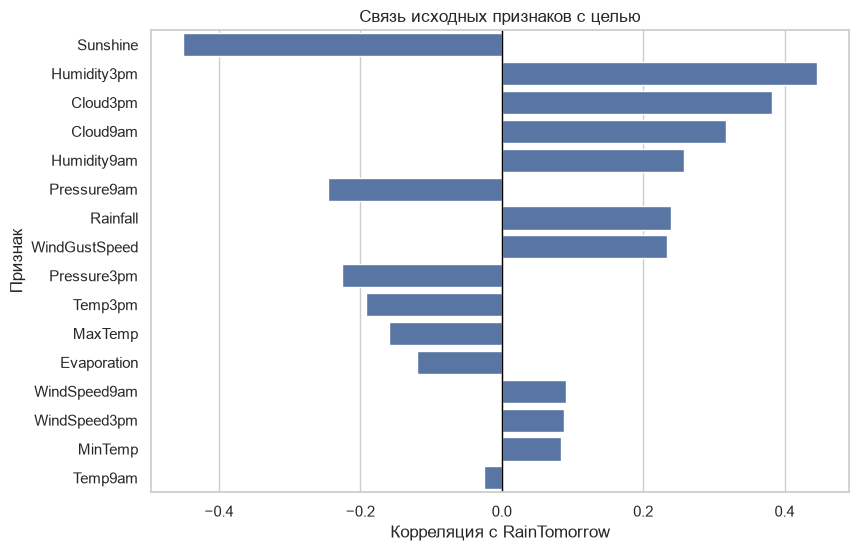

In [12]:
target_corr_before = (
    eda[original_numeric + ["target"]]
    .corr()["target"]
    .drop("target")
    .sort_values(key=abs, ascending=False)
)

display(target_corr_before.to_frame("correlation"))

plt.figure(figsize=(9, 6))
sns.barplot(
    x=target_corr_before.values,
    y=target_corr_before.index
)
plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Корреляция с RainTomorrow")
plt.ylabel("Признак")
plt.title("Связь исходных признаков с целью")
plt.show()

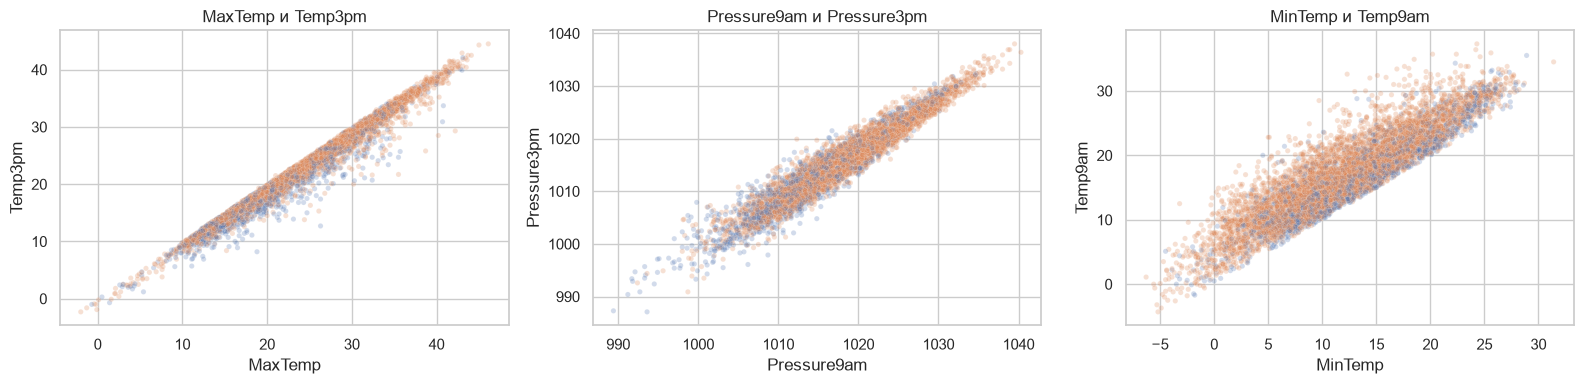

In [13]:
sample_corr = eda.sample(
    n=min(7000, len(eda)),
    random_state=42
)

pairs = [
    ("MaxTemp", "Temp3pm"),
    ("Pressure9am", "Pressure3pm"),
    ("MinTemp", "Temp9am")
]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (x_col, y_col) in zip(axes, pairs):
    sns.scatterplot(
        data=sample_corr,
        x=x_col,
        y=y_col,
        hue="RainTomorrow",
        alpha=0.25,
        s=14,
        ax=ax,
        legend=False
    )
    ax.set_title(f"{x_col} и {y_col}")

plt.tight_layout()
plt.show()

**Вывод:** наиболее сильные зависимости наблюдаются для пар
`MaxTemp–Temp3pm` (0.985), `Pressure9am–Pressure3pm` (0.961)
и `MinTemp–Temp9am` (0.902). Эти признаки частично дублируют друг друга.

С целью сильнее всего связаны `Sunshine`, `Humidity3pm`, облачность,
давление и текущие осадки. Корреляция показывает только линейную связь,
поэтому окончательный отбор выполняется по кросс-валидации.

## 6. Сезонность и циклическое время

In [14]:
eda["Year"] = eda["Date"].dt.year
eda["Month"] = eda["Date"].dt.month
eda["DayOfYear"] = eda["Date"].dt.dayofyear

eda["DayOfYear_sin"] = np.sin(
    2 * np.pi * eda["DayOfYear"] / 365.25
)
eda["DayOfYear_cos"] = np.cos(
    2 * np.pi * eda["DayOfYear"] / 365.25
)

monthly = (
    eda.groupby("Month")["target"]
    .agg(["mean", "count"])
)

display(monthly.round(3))

,mean,count
Month,,
1,0.193,12921
2,0.210,10525
3,0.213,13036
4,0.218,11306
5,0.225,13055
6,0.262,12389
7,0.269,11779
8,0.253,11762
9,0.230,11345


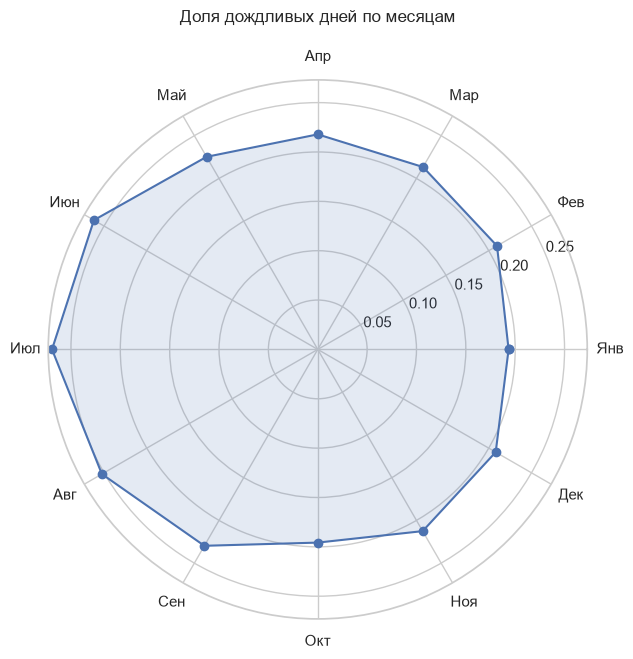

In [15]:
fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection="polar")

angles = 2 * np.pi * (monthly.index - 1) / 12
angles_closed = np.r_[angles, angles[0]]
rates_closed = np.r_[monthly["mean"].values, monthly["mean"].values[0]]

ax.plot(angles_closed, rates_closed, marker="o")
ax.fill(angles_closed, rates_closed, alpha=0.15)

ax.set_xticks(angles)
ax.set_xticklabels([
    "Янв", "Фев", "Мар", "Апр", "Май", "Июн",
    "Июл", "Авг", "Сен", "Окт", "Ноя", "Дек"
])
ax.set_title("Доля дождливых дней по месяцам", pad=20)

plt.show()

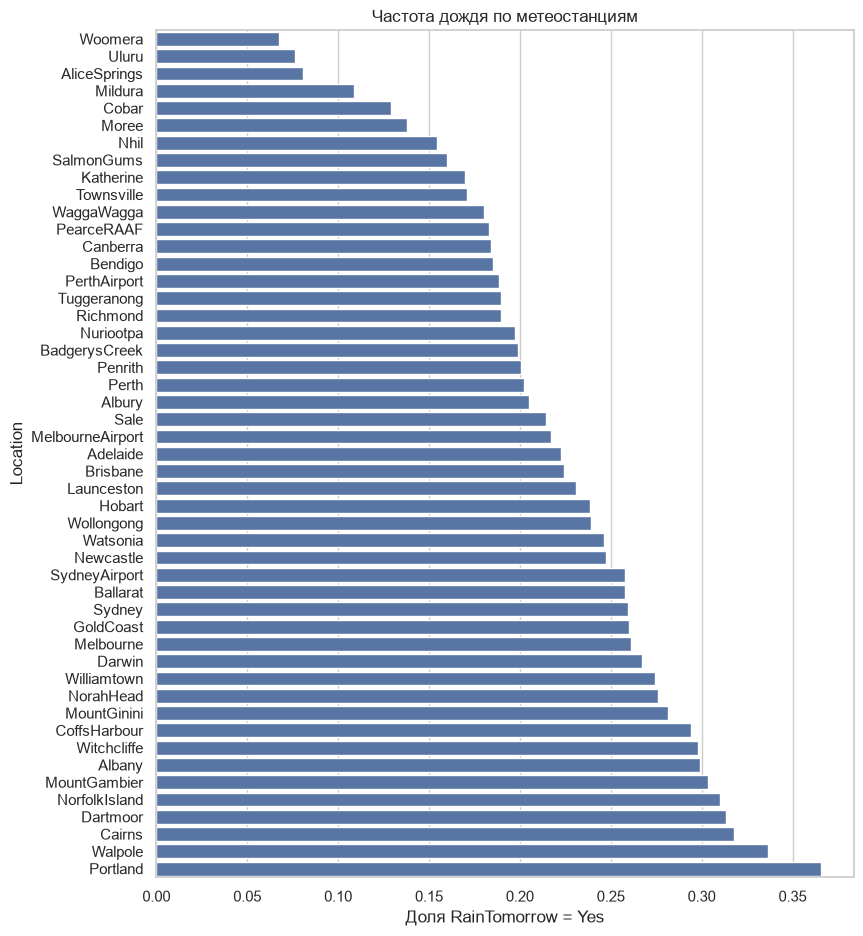

In [16]:
location_stats = (
    eda.groupby("Location")["target"]
    .agg(["mean", "count"])
    .sort_values("mean")
)

plt.figure(figsize=(9, 11))
sns.barplot(
    data=location_stats.reset_index(),
    x="mean",
    y="Location"
)
plt.xlabel("Доля RainTomorrow = Yes")
plt.ylabel("Location")
plt.title("Частота дождя по метеостанциям")
plt.show()

**Вывод:** доля дождливых дней меняется по месяцам и метеостанциям.
Например, по месяцам она возрастает примерно с 19% в январе до 27% в июле.
Гипотеза о сезонности и пространственных различиях подтверждается на уровне EDA.

В модель передаются `Location`, `DayOfYear_sin` и `DayOfYear_cos`.
Исходная дата и номер месяца отдельно не используются.

## 7. Создание новых признаков

In [17]:
# Разница между измерениями в 15:00 и 9:00
eda["TempChange"] = eda["Temp3pm"] - eda["Temp9am"]
eda["HumidityChange"] = eda["Humidity3pm"] - eda["Humidity9am"]
eda["PressureChange"] = eda["Pressure3pm"] - eda["Pressure9am"]
eda["WindSpeedChange"] = eda["WindSpeed3pm"] - eda["WindSpeed9am"]
eda["CloudChange"] = eda["Cloud3pm"] - eda["Cloud9am"]

# Суточный диапазон температуры
eda["TempRange"] = eda["MaxTemp"] - eda["MinTemp"]

# Преобразования признаков с правым хвостом
eda["Rainfall_log1p"] = np.log1p(eda["Rainfall"])
eda["Evaporation_log1p"] = np.log1p(eda["Evaporation"])

# Пропуски как отдельная информация
for col in ["Evaporation", "Sunshine", "Cloud9am", "Cloud3pm"]:
    eda[f"{col}_missing"] = eda[col].isna().astype("int8")

eda["MissingCount"] = eda.isna().sum(axis=1)

In [18]:
derived_features = [
    "TempChange", "TempRange",
    "HumidityChange", "PressureChange",
    "WindSpeedChange", "CloudChange",
    "DayOfYear_sin", "DayOfYear_cos",
    "Rainfall_log1p", "Evaporation_log1p",
    "Evaporation_missing", "Sunshine_missing",
    "Cloud9am_missing", "Cloud3pm_missing",
    "MissingCount"
]

derived_target_corr = (
    eda[derived_features + ["target"]]
    .corr()["target"]
    .drop("target")
    .sort_values(key=abs, ascending=False)
)

display(derived_target_corr.to_frame("correlation"))

,correlation
Rainfall_log1p,0.343700
TempRange,-0.337633
TempChange,-0.328107
HumidityChange,0.268333
Evaporation_log1p,-0.134986
PressureChange,0.080381
DayOfYear_cos,-0.051364
CloudChange,0.047007
Cloud3pm_missing,-0.041638
Cloud9am_missing,-0.026923


TempChange              TempRange              HumidityChange  \
                   mean median   std      mean median   std           mean   
RainTomorrow                                                                 
No                 5.40    5.2  3.42     11.94   11.5  4.81         -19.71   
Yes                2.59    2.2  3.17      7.93    7.2  4.10          -9.19   

                           PressureChange              WindSpeedChange         \
             median    std           mean median   std            mean median   
RainTomorrow                                                                    
No            -19.0  15.43          -2.48   -2.7  1.84            4.63    4.0   
Yes            -8.0  16.71          -2.10   -2.3  2.34            4.55    4.0   

                   CloudChange               
               std        mean median   std  
RainTomorrow                                 
No            8.55       -0.00    0.0  2.57  
Yes           8.99        0.27    0.0  2.22

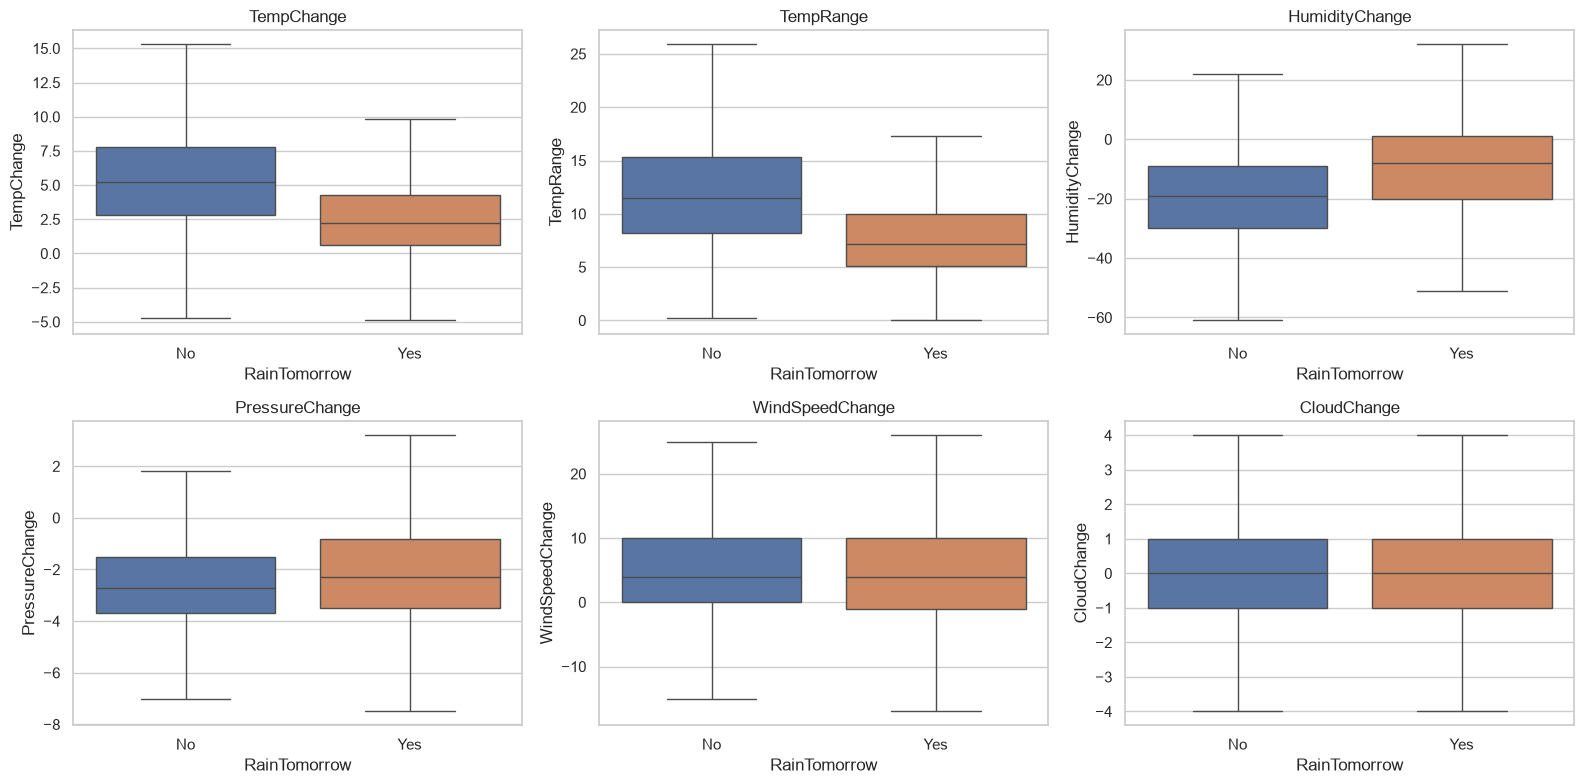

In [19]:
change_features = [
    "TempChange", "TempRange",
    "HumidityChange", "PressureChange",
    "WindSpeedChange", "CloudChange"
]

group_stats = (
    eda.groupby("RainTomorrow")[change_features]
    .agg(["mean", "median", "std"])
    .round(2)
)

display(group_stats)

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.ravel()

for ax, col in zip(axes, change_features):
    sns.boxplot(
        data=eda,
        x="RainTomorrow",
        y=col,
        hue="RainTomorrow",
        legend=False,
        showfliers=False,
        ax=ax
    )
    ax.set_title(col)

plt.tight_layout()
plt.show()

**Вывод:** среди новых признаков сильнее всего с целью связаны
`TempRange` (-0.338), `TempChange` (-0.328) и `HumidityChange` (0.268).
`WindSpeedChange` и `MissingCount` почти не связаны с целью.

`TempRange` и `TempChange` коррелируют примерно на 0.77,
поэтому необходимость хранить оба признака проверяется отдельным экспериментом.

## 8. Проверка логарифмирования

,before,after
Rainfall,9.888,2.047
Evaporation,3.747,-0.184


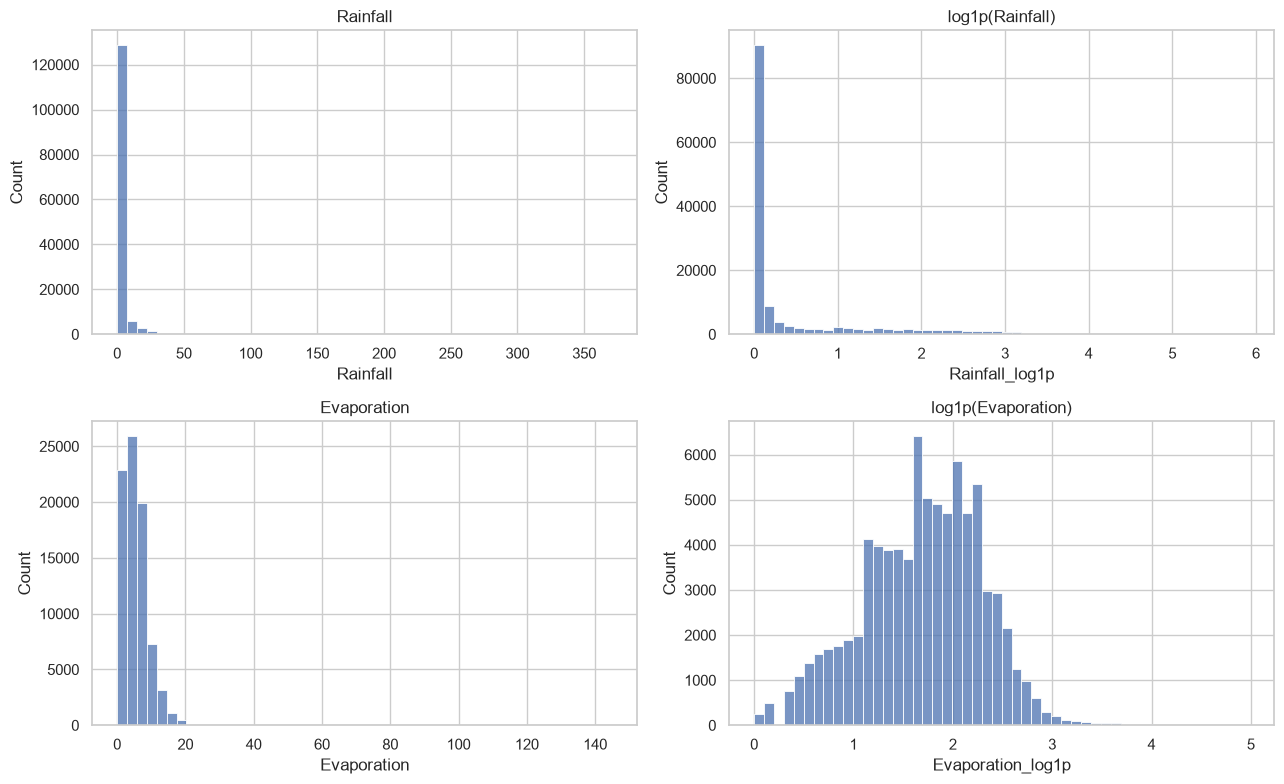

In [20]:
skew_compare = pd.DataFrame({
    "before": [
        eda["Rainfall"].skew(),
        eda["Evaporation"].skew()
    ],
    "after": [
        eda["Rainfall_log1p"].skew(),
        eda["Evaporation_log1p"].skew()
    ]
}, index=["Rainfall", "Evaporation"])

display(skew_compare.round(3))

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

sns.histplot(eda["Rainfall"], bins=50, ax=axes[0, 0])
axes[0, 0].set_title("Rainfall")

sns.histplot(eda["Rainfall_log1p"], bins=50, ax=axes[0, 1])
axes[0, 1].set_title("log1p(Rainfall)")

sns.histplot(eda["Evaporation"], bins=50, ax=axes[1, 0])
axes[1, 0].set_title("Evaporation")

sns.histplot(eda["Evaporation_log1p"], bins=50, ax=axes[1, 1])
axes[1, 1].set_title("log1p(Evaporation)")

plt.tight_layout()
plt.show()

In [21]:
rain_threshold = eda["Rainfall"] > 1.0

display(
    pd.crosstab(
        eda["RainToday"],
        rain_threshold,
        margins=True
    )
)

Rainfall,False,True,All
RainToday,,,
No,109332,0,109332
Yes,0,31455,31455
All,109332,31455,140787


**Вывод:** `log1p` заметно уменьшил асимметрию:
для `Rainfall` с 9.888 до 2.047, для `Evaporation` с 3.747 до -0.184.
При этом у `Rainfall` остаётся большая группа нулевых значений.

`RainToday` полностью соответствует порогу `Rainfall > 1`,
поэтому одновременно использовать оба исходных признака необязательно.
Далее сравниваются непрерывный, бинарный и двухчастный варианты `Rainfall`.

## 9. Корреляции после создания признаков

,correlation
Sunshine,-0.450768
Humidity3pm,0.446160
Cloud3pm,0.381870
Rainfall_log1p,0.343700
TempRange,-0.337633
TempChange,-0.328107
Cloud9am,0.317380
HumidityChange,0.268333
Humidity9am,0.257161
Pressure9am,-0.246371


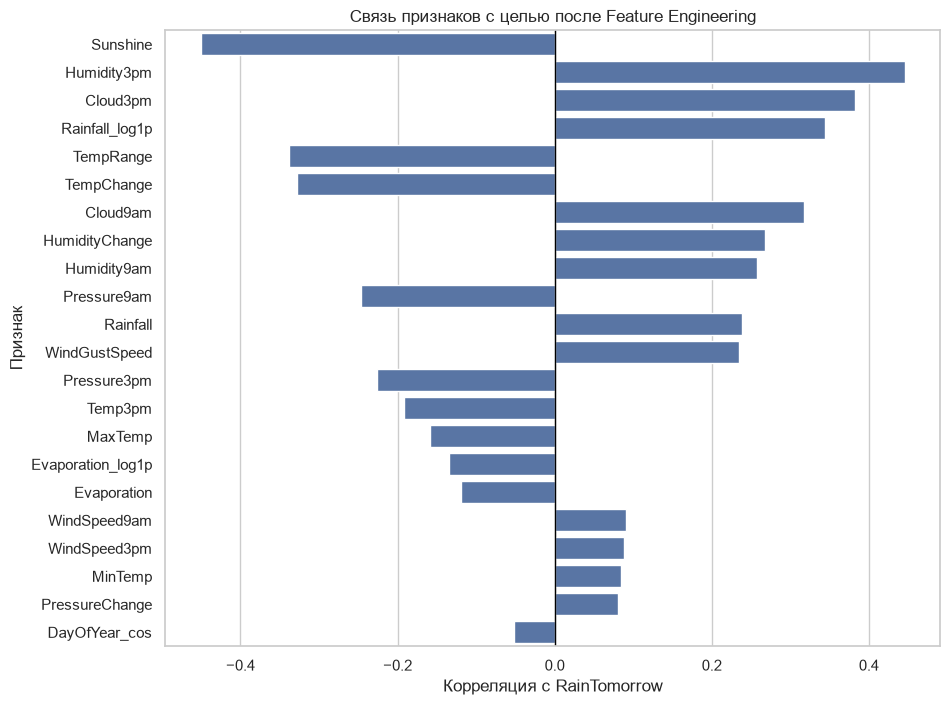

In [22]:
all_numeric_after = [
    col for col in eda.select_dtypes(include="number").columns
    if col not in ["target", "Year", "Month", "DayOfYear"]
]

target_corr_after = (
    eda[all_numeric_after + ["target"]]
    .corr()["target"]
    .drop("target")
    .sort_values(key=abs, ascending=False)
)

display(target_corr_after.to_frame("correlation").head(25))

plt.figure(figsize=(10, 8))
top_after = target_corr_after.head(22)

sns.barplot(
    x=top_after.values,
    y=top_after.index
)
plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Корреляция с RainTomorrow")
plt.ylabel("Признак")
plt.title("Связь признаков с целью после Feature Engineering")
plt.show()

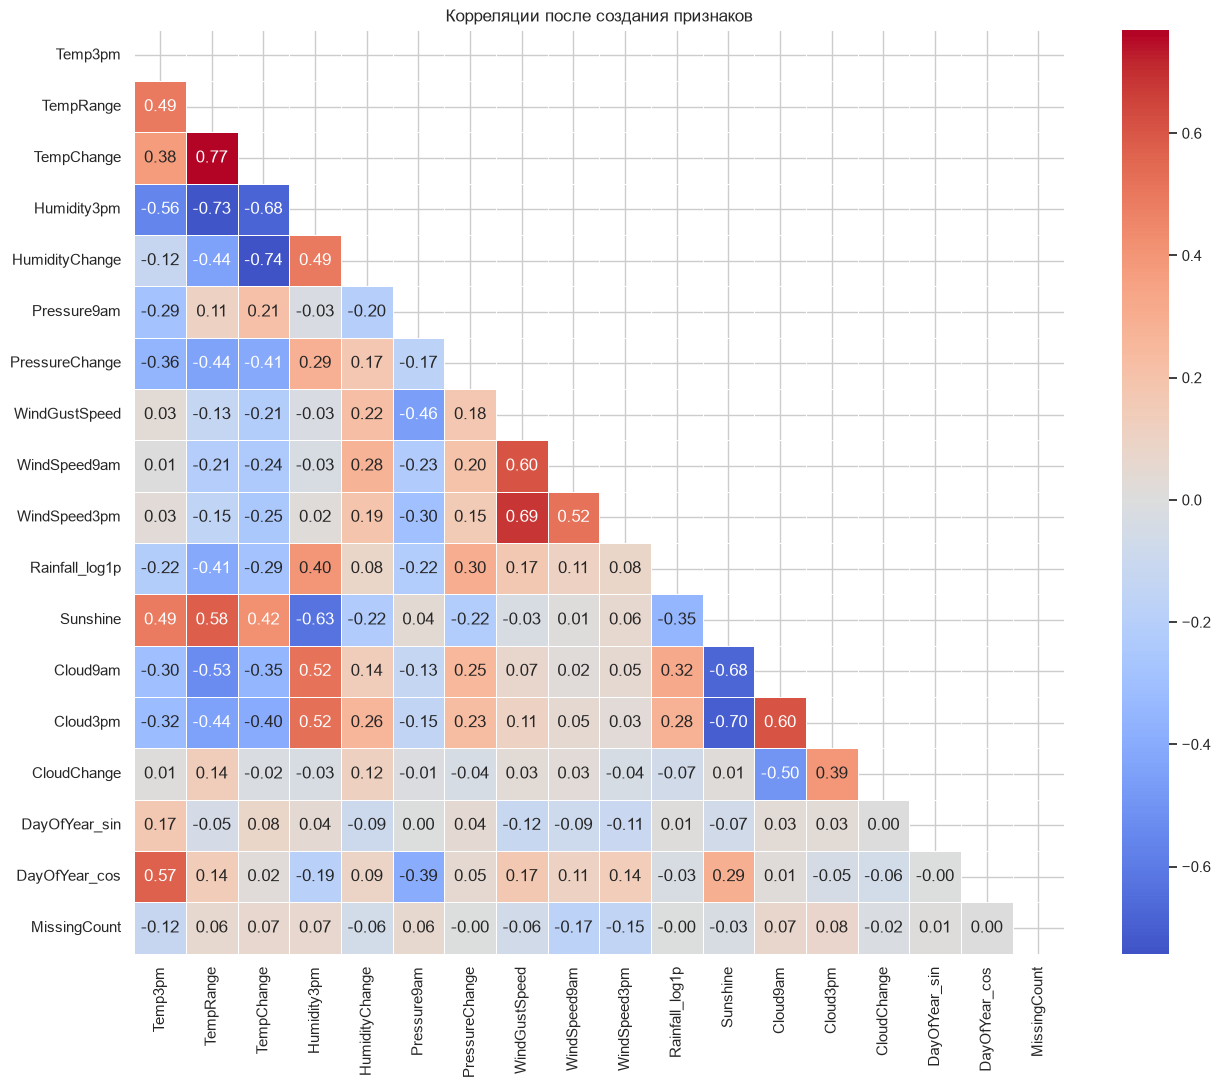

In [23]:
focused_corr_cols = [
    "Temp3pm", "TempRange", "TempChange",
    "Humidity3pm", "HumidityChange",
    "Pressure9am", "PressureChange",
    "WindGustSpeed", "WindSpeed9am", "WindSpeed3pm",
    "Rainfall_log1p", "Sunshine",
    "Cloud9am", "Cloud3pm", "CloudChange",
    "DayOfYear_sin", "DayOfYear_cos",
    "MissingCount"
]

focused_corr = eda[focused_corr_cols].corr()

plt.figure(figsize=(15, 12))
mask = np.triu(np.ones_like(focused_corr, dtype=bool))

sns.heatmap(
    focused_corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.4
)

plt.title("Корреляции после создания признаков")
plt.show()

In [24]:
corr_after = eda[all_numeric_after].corr()

upper_after = corr_after.where(
    np.triu(np.ones(corr_after.shape), k=1).astype(bool)
)

high_corr_after = (
    upper_after.stack()
    .rename("correlation")
    .reset_index()
    .rename(columns={
        "level_0": "feature_1",
        "level_1": "feature_2"
    })
)

high_corr_after = (
    high_corr_after[
        high_corr_after["correlation"].abs() >= 0.80
    ]
    .sort_values("correlation", key=abs, ascending=False)
)

display(high_corr_after.head(30))

,feature_1,feature_2,correlation
43,MaxTemp,Temp3pm,0.984562
253,Pressure9am,Pressure3pm,0.961348
13,MinTemp,Temp9am,0.901813
42,MaxTemp,Temp9am,0.887020
108,Evaporation,Evaporation_log1p,0.884136
325,Temp9am,Temp3pm,0.860574
455,Cloud9am_missing,Cloud3pm_missing,0.832634


**Вывод:** новые признаки не устранили всю избыточность.
Для линейной модели логично оставлять значение в 15:00 и изменение относительно 9:00,
а исходные значения в 9:00 проверить на удаление.

`TempRange` и `TempChange` связаны достаточно сильно, но корреляция ниже 0.8,
поэтому один из них удаляется только после сравнения PR-AUC.

## 10. Boxplot исходных и новых признаков

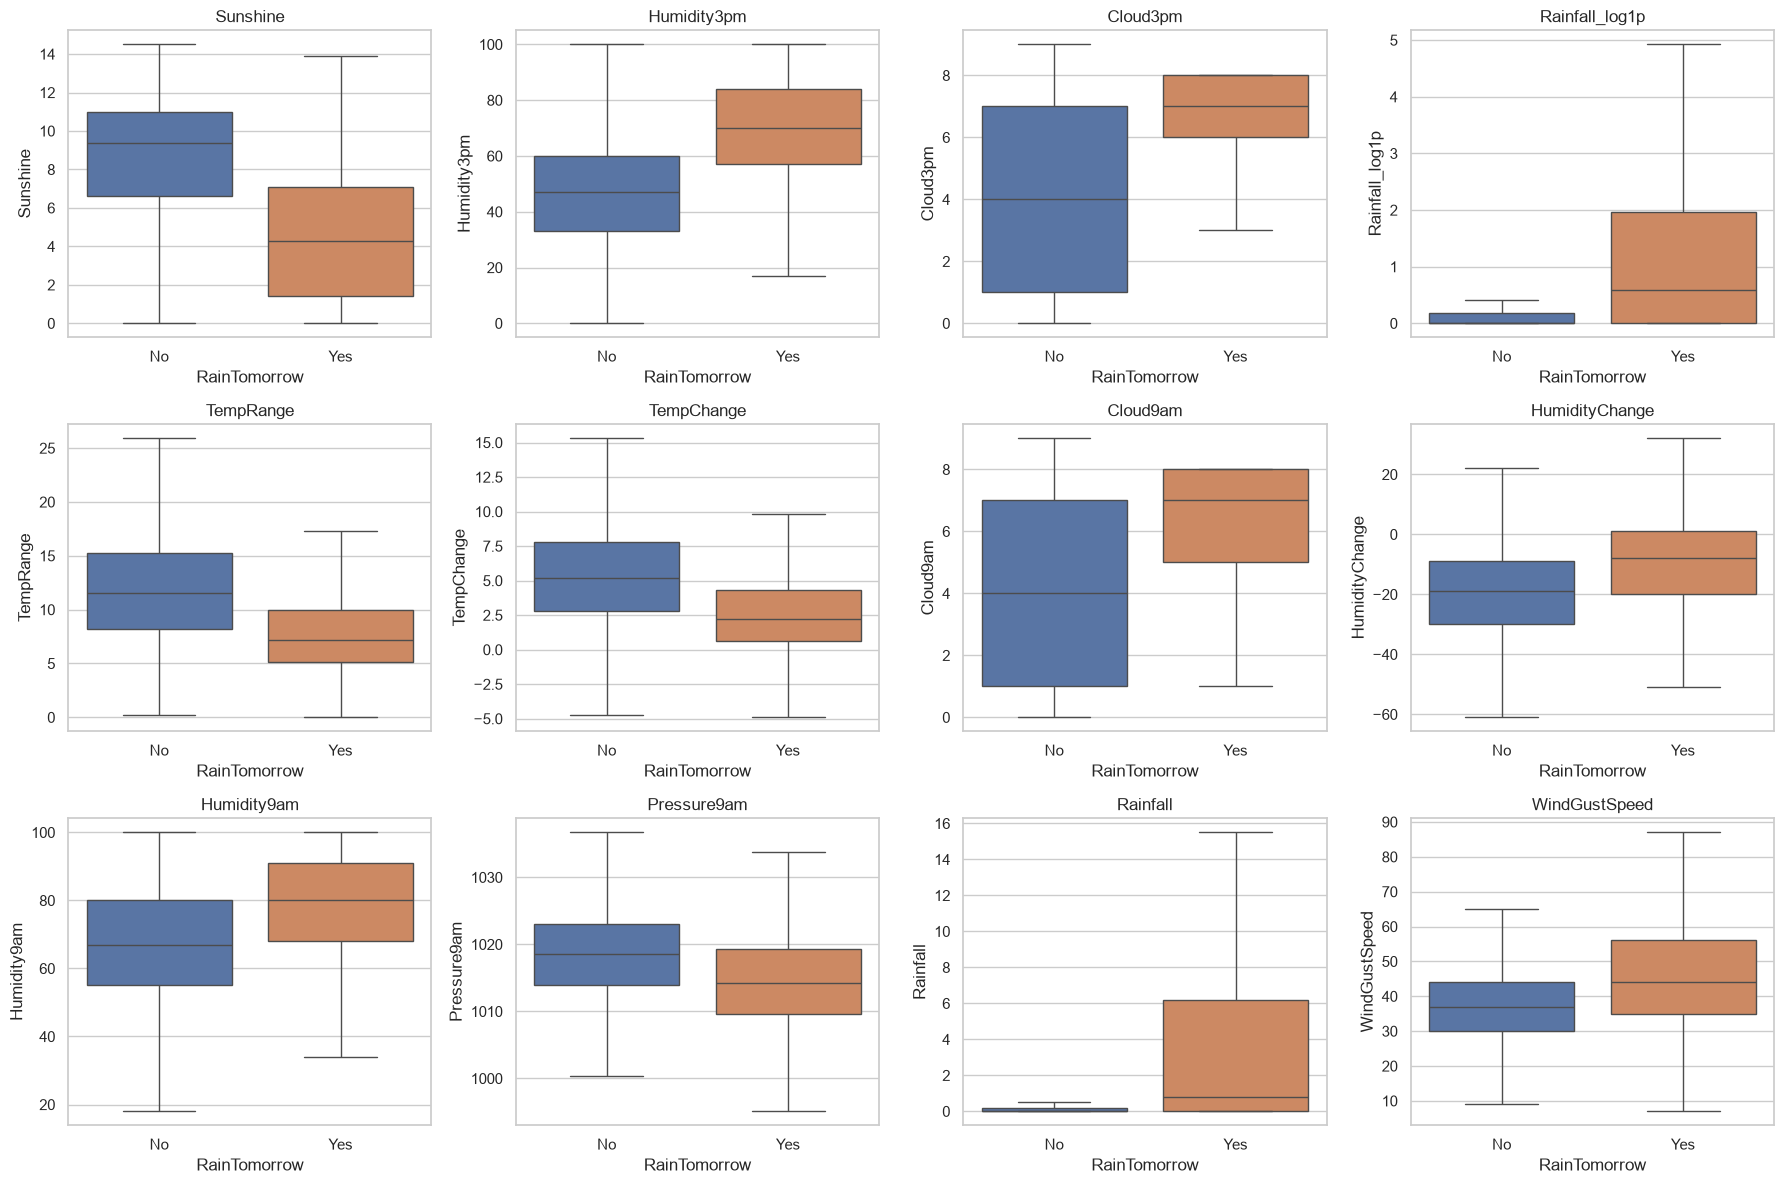

In [25]:
best_for_boxplot = (
    target_corr_after
    .drop(labels=[
        "Evaporation_missing", "Sunshine_missing",
        "Cloud9am_missing", "Cloud3pm_missing"
    ], errors="ignore")
    .head(12)
    .index
    .tolist()
)

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.ravel()

for ax, col in zip(axes, best_for_boxplot):
    sns.boxplot(
        data=eda,
        x="RainTomorrow",
        y=col,
        hue="RainTomorrow",
        legend=False,
        showfliers=False,
        ax=ax
    )
    ax.set_title(col)

plt.tight_layout()
plt.show()

**Вывод:** на boxplot наиболее заметно различаются классы по влажности в 15:00,
солнечному свету, облачности, осадкам и температурному диапазону.
Распределения всё равно пересекаются, поэтому одного признака для прогноза недостаточно.

## 11. Подготовка вариантов признаков

In [26]:
model_df = eda.copy()

model_df["RainfallOccurred"] = np.where(
    model_df["Rainfall"].isna(),
    np.nan,
    (model_df["Rainfall"] > 0).astype(float),
)

model_df["RainfallIsZero"] = np.where(
    model_df["Rainfall"].isna(),
    np.nan,
    (model_df["Rainfall"] == 0).astype(float),
)

model_df = (
    model_df
    .dropna(subset=["Date", "target"])
    .sort_values("Date")
    .reset_index(drop=True)
)

### Варианты данных для проверки гипотез

In [27]:
common_features = [
    "DayOfYear_sin",
    "DayOfYear_cos",

    "Temp3pm",
    "TempChange",
    "TempRange",

    "Humidity3pm",
    "HumidityChange",

    "Pressure3pm",
    "PressureChange",

    "WindGustSpeed",
    "WindSpeed3pm",

    "Cloud3pm",
    "Sunshine",
    "Evaporation_log1p",

    "Location",
    "WindGustDir",
    "WindDir9am",
    "WindDir3pm",
]

meta_columns = ["Date", "target"]

In [28]:
# H1: представление Rainfall
df_rain_log = model_df[
    meta_columns
    + common_features
    + ["Rainfall_log1p"]
].copy()

df_rain_binary = model_df[
    meta_columns
    + common_features
    + ["RainfallOccurred"]
].copy()

df_rain_two_part = model_df[
    meta_columns
    + common_features
    + ["Rainfall_log1p", "RainfallIsZero"]
].copy()

rain_variants = {
    "rain_log": df_rain_log,
    "rain_binary": df_rain_binary,
    "rain_two_part": df_rain_two_part,
}

In [29]:
# H2: TempRange и TempChange
df_temp_both = df_rain_log.copy()

df_temp_range = df_rain_log.drop(
    columns=["TempChange"]
).copy()

df_temp_change = df_rain_log.drop(
    columns=["TempRange"]
).copy()

temp_variants = {
    "temp_both": df_temp_both,
    "temp_range": df_temp_range,
    "temp_change": df_temp_change,
}

In [30]:
# H3: удаление признаков с большим количеством пропусков
df_missing_all = df_rain_log.copy()

df_without_evaporation = df_rain_log.drop(
    columns=["Evaporation_log1p"]
).copy()

df_without_high_missing = df_rain_log.drop(
    columns=[
        "Evaporation_log1p",
        "Sunshine",
        "Cloud3pm",
    ]
).copy()

missing_variants = {
    "missing_all": df_missing_all,
    "without_evaporation": df_without_evaporation,
    "without_high_missing": df_without_high_missing,
}

**Решение после EDA:** после создания разниц оставляю значение в 15:00
и изменение относительно 9:00. Исходные `Temp9am`, `Humidity9am`
и `Pressure9am` в варианты данных не включаются.

`WindSpeedChange`, `CloudChange` и `MissingCount` исключены как слабые признаки.
Исходный `Evaporation` заменён на `Evaporation_log1p`.

Для спорных решений созданы отдельные DataFrame:

- три представления `Rainfall`;
- оба температурных признака и каждый по отдельности;
- полный набор признаков с пропусками и два сокращённых варианта.

Все варианты дальше сравниваются на одинаковых временных фолдах.

## 12. Разделение данных и кросс-валидация

In [31]:
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    RandomizedSearchCV,
    cross_validate,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from scipy import sparse
from scipy.stats import randint

In [32]:
unique_dates = np.sort(model_df["Date"].unique())
cutoff_date = pd.Timestamp(
    unique_dates[int(len(unique_dates) * 0.80)]
)

train_mask = model_df["Date"] < cutoff_date
test_mask = ~train_mask

y_train = model_df.loc[train_mask, "target"].astype(int).reset_index(drop=True)
y_test = model_df.loc[test_mask, "target"].astype(int).reset_index(drop=True)

print("Граница train/test:", cutoff_date.date())
print("Train:", train_mask.sum())
print("Test:", test_mask.sum())
print("Доля класса Yes в train:", round(y_train.mean(), 3))
print("Доля класса Yes в test:", round(y_test.mean(), 3))

Граница train/test: 2015-08-08
Train: 109302
Test: 32891
Доля класса Yes в train: 0.226
Доля класса Yes в test: 0.219


In [33]:
def make_expanding_date_cv(dates, n_splits=4):
    dates = pd.Series(
        pd.to_datetime(dates)
    ).reset_index(drop=True)

    unique_dates = np.array(
        sorted(dates.unique())
    )

    blocks = np.array_split(
        unique_dates,
        n_splits + 1,
    )

    splits = []

    for fold in range(n_splits):
        train_dates = np.concatenate(
            blocks[:fold + 1]
        )
        valid_dates = blocks[fold + 1]

        train_idx = np.flatnonzero(
            dates.isin(train_dates).to_numpy()
        )
        valid_idx = np.flatnonzero(
            dates.isin(valid_dates).to_numpy()
        )

        splits.append(
            (train_idx, valid_idx)
        )

    return splits


train_dates = (
    model_df.loc[train_mask, "Date"]
    .reset_index(drop=True)
)

time_cv = make_expanding_date_cv(
    train_dates,
    n_splits=4,
)

**Пояснение:** последние 20% дат отложены в тест.
Кросс-валидация выполняется только внутри более раннего тренировочного периода.
Так модель не обучается на будущем и не возникает временной утечки.

## 13. Подготовка данных

In [34]:
def make_ohe():
    try:
        return OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=True,
        )
    except TypeError:
        return OneHotEncoder(
            handle_unknown="ignore",
            sparse=True,
        )


def split_feature_types(dataframe):
    features = dataframe.drop(
        columns=["Date", "target"]
    )

    categorical = features.select_dtypes(
        include=["object", "category", "string"]
    ).columns.tolist()

    numeric = [
        column
        for column in features.columns
        if column not in categorical
    ]

    return numeric, categorical


def make_preprocessor(
    dataframe,
    scale_numeric,
):
    numeric, categorical = split_feature_types(
        dataframe
    )

    numeric_steps = [
        (
            "imputer",
            SimpleImputer(
                strategy="median",
                add_indicator=True,
            ),
        )
    ]

    if scale_numeric:
        numeric_steps.append(
            ("scaler", StandardScaler())
        )

    numeric_pipeline = Pipeline(
        numeric_steps
    )

    categorical_pipeline = Pipeline([
        (
            "imputer",
            SimpleImputer(
                strategy="constant",
                fill_value="Missing",
            ),
        ),
        ("onehot", make_ohe()),
    ])

    return ColumnTransformer([
        (
            "numeric",
            numeric_pipeline,
            numeric,
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical,
        ),
    ])

In [35]:
SCORING = {
    "pr_auc": "average_precision",
    "roc_auc": "roc_auc",
    "f1": "f1",
    "recall": "recall",
    "precision": "precision",
    "balanced_accuracy": "balanced_accuracy",
}


def get_train_data(dataframe):
    X = dataframe.drop(
        columns=["Date", "target"]
    )

    return (
        X.loc[train_mask]
        .reset_index(drop=True)
    )


def get_test_data(dataframe):
    X = dataframe.drop(
        columns=["Date", "target"]
    )

    return (
        X.loc[test_mask]
        .reset_index(drop=True)
    )


def make_baseline_logreg(dataframe):
    return Pipeline([
        (
            "preprocessor",
            make_preprocessor(
                dataframe,
                scale_numeric=True,
            ),
        ),
        (
            "model",
            LogisticRegression(
                penalty="l2",
                C=1.0,
                max_iter=2500,
                solver="lbfgs",
                random_state=42,
            ),
        ),
    ])


def evaluate_variant(name, dataframe):
    model = make_baseline_logreg(
        dataframe
    )

    scores = cross_validate(
        model,
        get_train_data(dataframe),
        y_train,
        cv=time_cv,
        scoring=SCORING,
        n_jobs=-1,
    )

    row = {
        "variant": name,
        "features": (
            dataframe.shape[1] - 2
        ),
    }

    for metric in SCORING:
        row[metric] = scores[
            f"test_{metric}"
        ].mean()

        row[f"{metric}_std"] = scores[
            f"test_{metric}"
        ].std()

    return row


def compare_variants(variants):
    rows = [
        evaluate_variant(name, dataframe)
        for name, dataframe in variants.items()
    ]

    return (
        pd.DataFrame(rows)
        .set_index("variant")
        .sort_values(
            "pr_auc",
            ascending=False,
        )
    )

**Пояснение:** заполнение пропусков, One-Hot Encoding и масштабирование
выполняются внутри `Pipeline`. Поэтому медианы, категории и параметры
масштабирования вычисляются только по обучающей части каждого фолда.

Дерево не нуждается в масштабировании, а для логистической регрессии
оно необходимо из-за регуляризации и разного масштаба числовых признаков.

## 14. Проверка гипотез о признаках

In [36]:
rain_results = compare_variants(
    rain_variants
)

display(
    rain_results[
        [
            "features",
            "pr_auc",
            "pr_auc_std",
            "roc_auc",
            "f1",
            "recall",
            "precision",
        ]
    ].round(4)
)

,features,pr_auc,pr_auc_std,roc_auc,f1,recall,precision
variant,,,,,,,
rain_two_part,20,0.7079,0.0145,0.8714,0.6061,0.5205,0.7259
rain_log,19,0.7073,0.0143,0.8713,0.6058,0.5196,0.7266
rain_binary,19,0.7049,0.0149,0.8699,0.6034,0.5179,0.7233


**H1 — представление `Rainfall`.**

Максимальный PR-AUC получил двухчастный вариант: 0.7079.
Только `Rainfall_log1p` дал 0.7073, а бинарный вариант — 0.7049.

Преимущество двухчастного варианта над `Rainfall_log1p` равно только 0.0006,
что намного меньше порога 0.005. Гипотеза о заметной пользе отдельного признака нуля
**не подтвердилась**: практически достаточно одного `Rainfall_log1p`.
В автоматическом пайплайне оставлен формальный максимум — двухчастный вариант.

In [37]:
best_rain_name = rain_results.index[0]
best_rain_df = rain_variants[
    best_rain_name
].copy()

print(
    "Выбранный вариант Rainfall:",
    best_rain_name,
)

Выбранный вариант Rainfall: rain_two_part


In [38]:
# Температурные варианты строятся уже с выбранным представлением Rainfall.
temp_both_df = best_rain_df.copy()

temp_range_df = best_rain_df.drop(
    columns=["TempChange"]
).copy()

temp_change_df = best_rain_df.drop(
    columns=["TempRange"]
).copy()

temp_variants_selected_rain = {
    "temp_both": temp_both_df,
    "temp_range": temp_range_df,
    "temp_change": temp_change_df,
}

temp_results = compare_variants(
    temp_variants_selected_rain
)

display(
    temp_results[
        [
            "features",
            "pr_auc",
            "pr_auc_std",
            "roc_auc",
            "f1",
            "recall",
            "precision",
        ]
    ].round(4)
)

,features,pr_auc,pr_auc_std,roc_auc,f1,recall,precision
variant,,,,,,,
temp_range,19,0.7080,0.0144,0.8715,0.6062,0.5203,0.7267
temp_both,20,0.7079,0.0145,0.8714,0.6061,0.5205,0.7259
temp_change,19,0.7078,0.0141,0.8712,0.6053,0.5186,0.7274


**H2 — `TempRange` и `TempChange`.**

PR-AUC составил 0.7080 только для `TempRange`,
0.7079 для обоих признаков и 0.7078 только для `TempChange`.

Добавление двух коррелирующих признаков одновременно не улучшило качество.
Гипотеза **подтвердилась**: оставляю `TempRange`, а `TempChange` удаляю.

In [39]:
best_temp_name = temp_results.index[0]
best_temp_df = temp_variants_selected_rain[
    best_temp_name
].copy()

print(
    "Выбранный температурный вариант:",
    best_temp_name,
)

Выбранный температурный вариант: temp_range


In [40]:
missing_all_df = best_temp_df.copy()

without_evaporation_df = best_temp_df.drop(
    columns=["Evaporation_log1p"],
    errors="ignore",
).copy()

without_high_missing_df = best_temp_df.drop(
    columns=[
        "Evaporation_log1p",
        "Sunshine",
        "Cloud3pm",
    ],
    errors="ignore",
).copy()

missing_variants_selected = {
    "missing_all": missing_all_df,
    "without_evaporation": without_evaporation_df,
    "without_high_missing": without_high_missing_df,
}

missing_results = compare_variants(
    missing_variants_selected
)

display(
    missing_results[
        [
            "features",
            "pr_auc",
            "pr_auc_std",
            "roc_auc",
            "f1",
            "recall",
            "precision",
        ]
    ].round(4)
)

,features,pr_auc,pr_auc_std,roc_auc,f1,recall,precision
variant,,,,,,,
missing_all,19,0.7080,0.0144,0.8715,0.6062,0.5203,0.7267
without_evaporation,18,0.7074,0.0147,0.8714,0.6061,0.5199,0.7271
without_high_missing,16,0.6992,0.0159,0.8628,0.6004,0.5102,0.7298


**H3 — признаки с большим числом пропусков.**

Полный набор дал PR-AUC 0.7080.
После удаления только `Evaporation_log1p` результат составил 0.7074:
потеря 0.0006 практически незначима.

Удаление одновременно `Evaporation_log1p`, `Sunshine` и `Cloud3pm`
снизило PR-AUC до 0.6992. Значит, `Evaporation_log1p` можно убрать,
но `Sunshine` и `Cloud3pm` содержат полезную информацию.

Для дальнейшего автоматического пайплайна оставлен абсолютный максимум — полный набор.

In [41]:
best_missing_name = missing_results.index[0]
final_df = missing_variants_selected[
    best_missing_name
].copy()

print(
    "Итоговый вариант данных:",
    best_missing_name,
)
print(
    "Количество признаков до One-Hot:",
    final_df.shape[1] - 2,
)

Итоговый вариант данных: missing_all
Количество признаков до One-Hot: 19


## 15. Базовые модели

In [42]:
def make_linear_pipeline(
    dataframe,
    penalty,
    C,
    solver,
    class_weight=None,
):
    return Pipeline([
        (
            "preprocessor",
            make_preprocessor(
                dataframe,
                scale_numeric=True,
            ),
        ),
        (
            "model",
            LogisticRegression(
                penalty=penalty,
                C=C,
                solver=solver,
                class_weight=class_weight,
                max_iter=3000,
                random_state=42,
            ),
        ),
    ])


def make_tree_pipeline(dataframe):
    return Pipeline([
        (
            "preprocessor",
            make_preprocessor(
                dataframe,
                scale_numeric=False,
            ),
        ),
        (
            "model",
            DecisionTreeClassifier(
                max_depth=8,
                min_samples_leaf=20,
                random_state=42,
            ),
        ),
    ])


baseline_models = {
    "Dummy": Pipeline([
        (
            "preprocessor",
            make_preprocessor(
                final_df,
                scale_numeric=True,
            ),
        ),
        (
            "model",
            DummyClassifier(
                strategy="prior",
            ),
        ),
    ]),

    "LogReg": make_linear_pipeline(
        final_df,
        penalty="l2",
        C=10000.0,
        solver="lbfgs",
    ),

    "LogReg L2": make_linear_pipeline(
        final_df,
        penalty="l2",
        C=1.0,
        solver="lbfgs",
    ),

    "LogReg L1": make_linear_pipeline(
        final_df,
        penalty="l1",
        C=1.0,
        solver="liblinear",
    ),

    "Decision Tree": make_tree_pipeline(
        final_df
    ),
}

In [43]:
def evaluate_model_cv(name, model):
    scores = cross_validate(
        model,
        get_train_data(final_df),
        y_train,
        cv=time_cv,
        scoring=SCORING,
        n_jobs=-1,
        return_train_score=True,
    )

    row = {"model": name}

    for metric in SCORING:
        row[metric] = scores[
            f"test_{metric}"
        ].mean()

        row[f"{metric}_std"] = scores[
            f"test_{metric}"
        ].std()

    row["train_pr_auc"] = scores[
        "train_pr_auc"
    ].mean()

    return row


baseline_results = pd.DataFrame([
    evaluate_model_cv(name, model)
    for name, model in baseline_models.items()
]).set_index("model")

baseline_results = baseline_results.sort_values(
    "pr_auc",
    ascending=False,
)

display(
    baseline_results[
        [
            "pr_auc",
            "pr_auc_std",
            "roc_auc",
            "f1",
            "recall",
            "precision",
            "balanced_accuracy",
            "train_pr_auc",
        ]
    ].round(4)
)

,pr_auc,pr_auc_std,roc_auc,f1,recall,precision,balanced_accuracy,train_pr_auc
model,,,,,,,,
LogReg L1,0.7087,0.0141,0.8720,0.6071,0.5206,0.7288,0.7317,0.7261
LogReg L2,0.7080,0.0144,0.8715,0.6062,0.5203,0.7267,0.7312,0.7263
LogReg,0.7069,0.0150,0.8707,0.6051,0.5188,0.7262,0.7305,0.7264
Decision Tree,0.6524,0.0125,0.8411,0.5765,0.4958,0.6894,0.7147,0.7338
Dummy,0.2285,0.0147,0.5000,0.0000,0.0000,0.0000,0.5000,0.2205


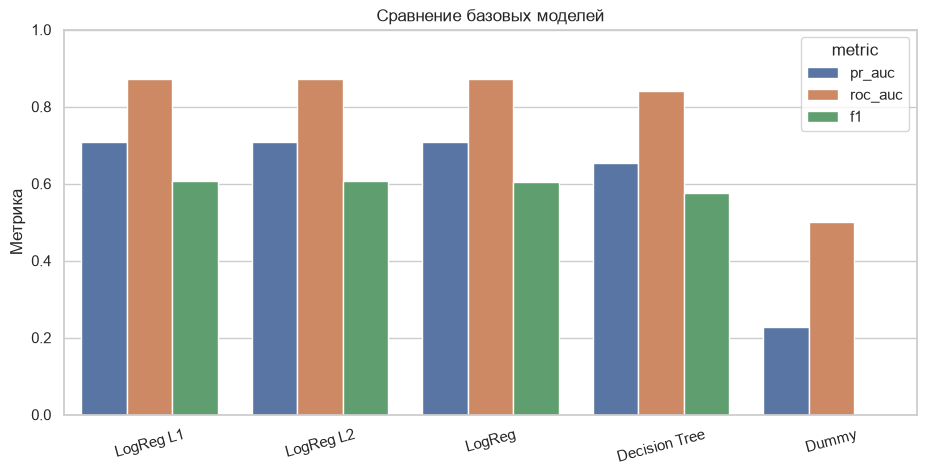

In [44]:
baseline_long = (
    baseline_results[
        ["pr_auc", "roc_auc", "f1"]
    ]
    .reset_index()
    .melt(
        id_vars="model",
        var_name="metric",
        value_name="score",
    )
)

plt.figure(figsize=(11, 5))

sns.barplot(
    data=baseline_long,
    x="model",
    y="score",
    hue="metric",
)

plt.ylim(0, 1)
plt.xlabel("")
plt.ylabel("Метрика")
plt.title("Сравнение базовых моделей")
plt.xticks(rotation=15)
plt.show()

**Вывод:** все варианты логистической регрессии значительно превосходят DummyClassifier
и одиночное дерево. Лучший базовый результат показала L1-модель: PR-AUC 0.7087.
L2 получила 0.7080, обычная LogReg — 0.7069, дерево — 0.6524.

Разница между линейными моделями небольшая, но регуляризация немного улучшила
качество и стабильность. Гипотеза о преимуществе регуляризованной линейной модели
над одиночным деревом **подтвердилась**.

## 16. Проверка переобучения дерева

In [45]:
depth_values = [
    2,
    3,
    4,
    5,
    7,
    10,
    15,
    None,
]

depth_rows = []

for depth in depth_values:
    model = Pipeline([
        (
            "preprocessor",
            make_preprocessor(
                final_df,
                scale_numeric=False,
            ),
        ),
        (
            "model",
            DecisionTreeClassifier(
                max_depth=depth,
                min_samples_leaf=20,
                random_state=42,
            ),
        ),
    ])

    scores = cross_validate(
        model,
        get_train_data(final_df),
        y_train,
        cv=time_cv,
        scoring="average_precision",
        n_jobs=-1,
        return_train_score=True,
    )

    depth_rows.append({
        "max_depth": (
            "None"
            if depth is None
            else str(depth)
        ),
        "train_pr_auc": scores[
            "train_score"
        ].mean(),
        "valid_pr_auc": scores[
            "test_score"
        ].mean(),
    })

depth_results = pd.DataFrame(
    depth_rows
)

display(depth_results.round(4))

,max_depth,train_pr_auc,valid_pr_auc
0,2,0.5169,0.5080
1,3,0.5855,0.5715
2,4,0.6292,0.6079
3,5,0.6636,0.6289
4,7,0.7143,0.6515
5,10,0.7644,0.6457
6,15,0.7976,0.6312
7,None,0.8049,0.6248


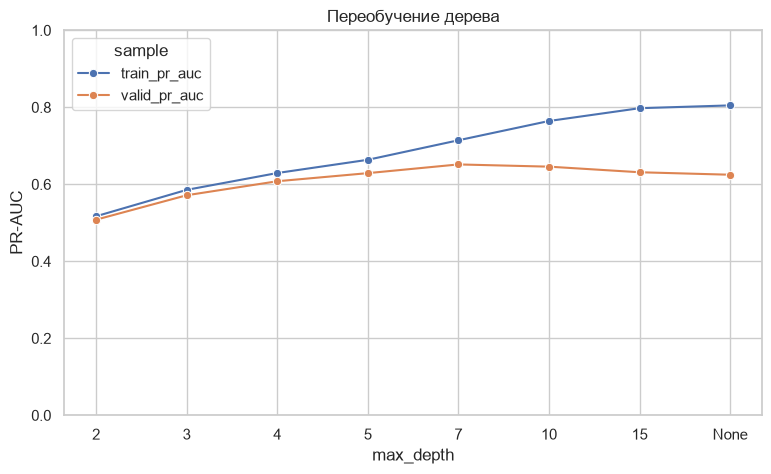

In [46]:
depth_long = depth_results.melt(
    id_vars="max_depth",
    value_vars=[
        "train_pr_auc",
        "valid_pr_auc",
    ],
    var_name="sample",
    value_name="pr_auc",
)

plt.figure(figsize=(9, 5))

sns.lineplot(
    data=depth_long,
    x="max_depth",
    y="pr_auc",
    hue="sample",
    marker="o",
)

plt.ylim(0, 1)
plt.xlabel("max_depth")
plt.ylabel("PR-AUC")
plt.title("Переобучение дерева")
plt.show()

**Вывод:** validation PR-AUC растёт до глубины 7 и достигает 0.6515.
При дальнейшем увеличении глубины train PR-AUC продолжает расти
с 0.7143 до 0.8049, а validation PR-AUC падает до 0.6248.

Дерево начинает переобучаться после глубины около 7.
Гипотеза о переобучении глубокого дерева **подтвердилась**.

## 17. Подбор гиперпараметров

In [47]:
l2_pipeline = make_linear_pipeline(
    final_df,
    penalty="l2",
    C=1.0,
    solver="lbfgs",
)

l2_grid = {
    "model__C": [
        0.01,
        0.1,
        1.0,
        10.0,
        100.0,
    ],
    "model__class_weight": [
        None,
        "balanced",
    ],
}

l2_search = GridSearchCV(
    estimator=l2_pipeline,
    param_grid=l2_grid,
    scoring=SCORING,
    refit="pr_auc",
    cv=time_cv,
    n_jobs=-1,
    return_train_score=True,
)

l2_search.fit(
    get_train_data(final_df),
    y_train,
)

print(l2_search.best_params_)
print(
    "CV PR-AUC:",
    round(l2_search.best_score_, 4),
)

c:\work_projects\problem_clustering\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


{'model__C': 0.1, 'model__class_weight': None}
CV PR-AUC: 0.7096


In [48]:
l1_pipeline = make_linear_pipeline(
    final_df,
    penalty="l1",
    C=1.0,
    solver="liblinear",
)

l1_grid = {
    "model__C": [
        0.01,
        0.1,
        1.0,
        10.0,
        100.0,
    ],
    "model__class_weight": [
        None,
        "balanced",
    ],
}

l1_search = GridSearchCV(
    estimator=l1_pipeline,
    param_grid=l1_grid,
    scoring=SCORING,
    refit="pr_auc",
    cv=time_cv,
    n_jobs=-1,
    return_train_score=True,
)

l1_search.fit(
    get_train_data(final_df),
    y_train,
)

print(l1_search.best_params_)
print(
    "CV PR-AUC:",
    round(l1_search.best_score_, 4),
)

c:\work_projects\problem_clustering\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\work_projects\problem_clustering\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


{'model__C': 0.1, 'model__class_weight': None}
CV PR-AUC: 0.7094


In [49]:
tree_pipeline = make_tree_pipeline(
    final_df
)

tree_parameters = {
    "model__criterion": [
        "gini",
        "entropy",
        "log_loss",
    ],
    "model__max_depth": [
        3,
        4,
        5,
        7,
        10,
        15,
        None,
    ],
    "model__min_samples_split": randint(
        2,
        151,
    ),
    "model__min_samples_leaf": randint(
        1,
        101,
    ),
    "model__max_leaf_nodes": [
        None,
        15,
        30,
        50,
        100,
        200,
    ],
    "model__class_weight": [
        None,
        "balanced",
    ],
    "model__ccp_alpha": [
        0.0,
        0.0001,
        0.0005,
        0.001,
        0.005,
    ],
}

tree_search = RandomizedSearchCV(
    estimator=tree_pipeline,
    param_distributions=tree_parameters,
    n_iter=35,
    scoring=SCORING,
    refit="pr_auc",
    cv=time_cv,
    n_jobs=-1,
    random_state=42,
    return_train_score=True,
)

tree_search.fit(
    get_train_data(final_df),
    y_train,
)

print(tree_search.best_params_)
print(
    "CV PR-AUC:",
    round(tree_search.best_score_, 4),
)

{'model__ccp_alpha': 0.0, 'model__class_weight': 'balanced', 'model__criterion': 'gini', 'model__max_depth': 15, 'model__max_leaf_nodes': None, 'model__min_samples_leaf': 58, 'model__min_samples_split': 53}
CV PR-AUC: 0.6575


**Вывод по подбору:** для L2 и L1 лучшим оказалось `C=0.1`
без `class_weight='balanced'`. Их CV PR-AUC равен 0.7096 и 0.7094.

Подбор дерева повысил PR-AUC с 0.6524 до 0.6575,
но оно всё равно уступило линейным моделям.
Лучшее дерево использует `class_weight='balanced'`, поэтому сильнее ориентируется
на обнаружение класса `Yes`.

## 18. Отбор признаков

In [50]:
selector_estimator = LogisticRegression(
    penalty="l1",
    C=l1_search.best_params_["model__C"],
    class_weight=l1_search.best_params_[
        "model__class_weight"
    ],
    solver="liblinear",
    max_iter=3000,
    random_state=42,
)

selection_pipeline = Pipeline([
    (
        "preprocessor",
        make_preprocessor(
            final_df,
            scale_numeric=True,
        ),
    ),
    (
        "selector",
        SelectFromModel(
            estimator=selector_estimator,
            threshold=1e-8,
        ),
    ),
    (
        "model",
        LogisticRegression(
            penalty="l2",
            C=l2_search.best_params_["model__C"],
            class_weight=l2_search.best_params_[
                "model__class_weight"
            ],
            solver="lbfgs",
            max_iter=3000,
            random_state=42,
        ),
    ),
])

selection_scores = cross_validate(
    selection_pipeline,
    get_train_data(final_df),
    y_train,
    cv=time_cv,
    scoring=SCORING,
    n_jobs=-1,
)

selection_pipeline.fit(
    get_train_data(final_df),
    y_train,
)

all_encoded_features = (
    selection_pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

selected_mask = (
    selection_pipeline
    .named_steps["selector"]
    .get_support()
)

print(
    "Выбрано признаков:",
    selected_mask.sum(),
    "из",
    len(selected_mask),
)

display(
    pd.Series(
        all_encoded_features[selected_mask],
        name="selected_feature",
    ).head(40)
)

c:\work_projects\problem_clustering\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\work_projects\problem_clustering\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\work_projects\problem_clustering\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use

Выбрано признаков: 114 из 128


0                          numeric__DayOfYear_sin
1                          numeric__DayOfYear_cos
2                                numeric__Temp3pm
3                              numeric__TempRange
4                            numeric__Humidity3pm
5                         numeric__HumidityChange
6                            numeric__Pressure3pm
7                         numeric__PressureChange
8                          numeric__WindGustSpeed
9                           numeric__WindSpeed3pm
10                              numeric__Cloud3pm
11                              numeric__Sunshine
12                     numeric__Evaporation_log1p
13                        numeric__Rainfall_log1p
14                        numeric__RainfallIsZero
15              numeric__missingindicator_Temp3pm
16            numeric__missingindicator_TempRange
17          numeric__missingindicator_Humidity3pm
18       numeric__missingindicator_HumidityChange
19          numeric__missingindicator_Pressure3pm


**Вывод:** L1-отбор оставил 114 из 128 признаков, то есть удалил только 14.
PR-AUC связки `L1 selection + L2` составил 0.7098 против 0.7096 у обычной L2.

Гипотеза о сохранении качества **подтвердилась**, но отбор получился слабым:
размерность уменьшилась примерно на 11%, а прирост качества составил только 0.0002.

## 19. Финальная оценка

In [51]:
def best_search_metrics(
    search,
    name,
):
    index = search.best_index_
    results = search.cv_results_

    return {
        "model": name,
        "pr_auc": results[
            "mean_test_pr_auc"
        ][index],
        "roc_auc": results[
            "mean_test_roc_auc"
        ][index],
        "f1": results[
            "mean_test_f1"
        ][index],
        "recall": results[
            "mean_test_recall"
        ][index],
        "precision": results[
            "mean_test_precision"
        ][index],
    }


selection_cv_row = {
    "model": "L1 selection + L2",
}

for metric in SCORING:
    selection_cv_row[metric] = (
        selection_scores[
            f"test_{metric}"
        ].mean()
    )

tuned_cv_results = pd.DataFrame([
    best_search_metrics(
        l2_search,
        "LogReg L2",
    ),
    best_search_metrics(
        l1_search,
        "LogReg L1",
    ),
    best_search_metrics(
        tree_search,
        "Decision Tree",
    ),
    selection_cv_row,
]).set_index("model")

tuned_cv_results = (
    tuned_cv_results
    .sort_values(
        "pr_auc",
        ascending=False,
    )
)

display(tuned_cv_results.round(4))

,pr_auc,roc_auc,f1,recall,precision,balanced_accuracy
model,,,,,,
L1 selection + L2,0.7098,0.8731,0.6082,0.5216,0.7298,0.7323
LogReg L2,0.7096,0.8730,0.6078,0.5214,0.7291,NaN
LogReg L1,0.7094,0.8732,0.6071,0.5205,0.7285,NaN
Decision Tree,0.6575,0.8421,0.5895,0.7616,0.4815,NaN


**Вывод:** все линейные модели показали почти одинаковое качество.
Формально лучшей стала `L1 selection + L2` с PR-AUC 0.7098,
но её преимущество над L2 и L1 меньше 0.0005.

Дерево уступает по PR-AUC, зато на кросс-валидации имеет более высокий recall
и значительно более низкий precision. Оно чаще находит дождливые дни,
но создаёт больше ложных срабатываний.

In [52]:
final_models = {
    "LogReg L2": l2_search.best_estimator_,
    "LogReg L1": l1_search.best_estimator_,
    "Decision Tree": tree_search.best_estimator_,
    "L1 selection + L2": selection_pipeline,
}

selected_model_name = (
    tuned_cv_results.index[0]
)

print(
    "Модель выбрана по CV:",
    selected_model_name,
)

Модель выбрана по CV: L1 selection + L2


In [53]:
def evaluate_test(name, model):
    probabilities = model.predict_proba(
        get_test_data(final_df)
    )[:, 1]

    predictions = (
        probabilities >= 0.5
    ).astype(int)

    return {
        "model": name,
        "accuracy": accuracy_score(
            y_test,
            predictions,
        ),
        "balanced_accuracy": (
            balanced_accuracy_score(
                y_test,
                predictions,
            )
        ),
        "precision": precision_score(
            y_test,
            predictions,
            zero_division=0,
        ),
        "recall": recall_score(
            y_test,
            predictions,
        ),
        "f1": f1_score(
            y_test,
            predictions,
        ),
        "roc_auc": roc_auc_score(
            y_test,
            probabilities,
        ),
        "pr_auc": average_precision_score(
            y_test,
            probabilities,
        ),
    }


test_results = pd.DataFrame([
    evaluate_test(name, model)
    for name, model in final_models.items()
]).set_index("model")

test_results = test_results.sort_values(
    "pr_auc",
    ascending=False,
)

display(test_results.round(4))

,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc
model,,,,,,,
L1 selection + L2,0.8478,0.7216,0.7223,0.4967,0.5887,0.8653,0.6902
LogReg L2,0.8477,0.7216,0.7217,0.4970,0.5887,0.8652,0.6900
LogReg L1,0.8480,0.7215,0.7236,0.4962,0.5887,0.8650,0.6899
Decision Tree,0.7653,0.7563,0.4773,0.7401,0.5804,0.8384,0.6465


**Вывод на тесте:** порядок моделей сохранился.
`L1 selection + L2` получила PR-AUC 0.6902 и ROC-AUC 0.8653.
L2 и L1 дали практически те же результаты: 0.6900 и 0.6899 по PR-AUC.

Снижение PR-AUC относительно кросс-валидации примерно на 0.02 показывает,
что более поздний тестовый период оказался немного сложнее.

При пороге 0.5 линейная модель имеет precision 0.7223 и recall 0.4967.
Дерево повышает recall до 0.7401, но снижает precision до 0.4773.

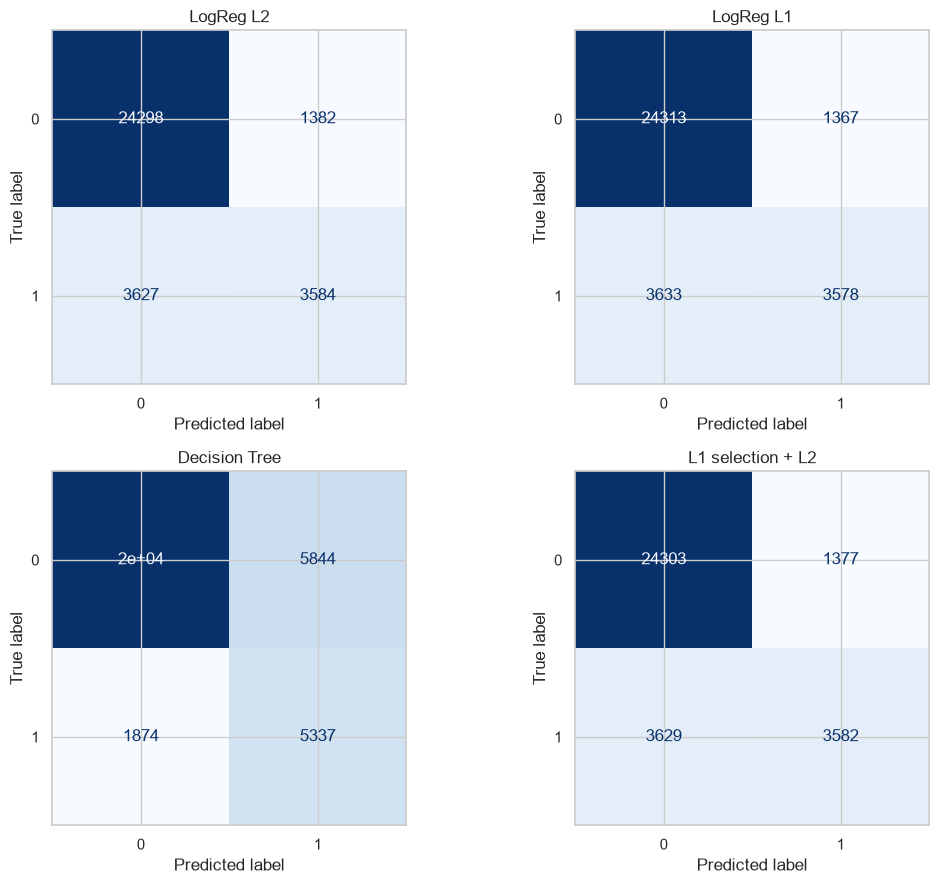

In [54]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(11, 9),
)

for ax, (name, model) in zip(
    axes.ravel(),
    final_models.items(),
):
    ConfusionMatrixDisplay.from_estimator(
        model,
        get_test_data(final_df),
        y_test,
        cmap="Blues",
        colorbar=False,
        ax=ax,
    )

    ax.set_title(name)

plt.tight_layout()
plt.show()

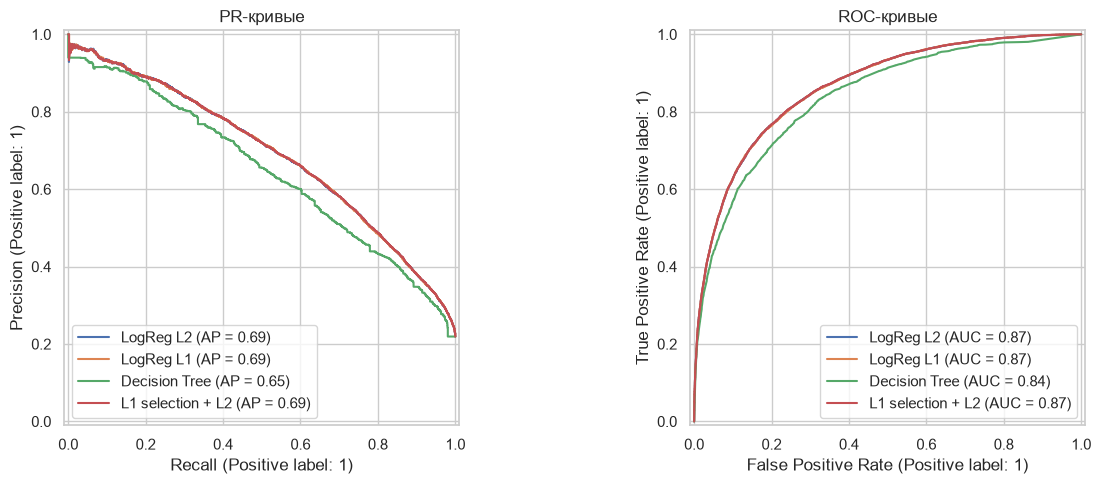

In [55]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 5),
)

for name, model in final_models.items():
    PrecisionRecallDisplay.from_estimator(
        model,
        get_test_data(final_df),
        y_test,
        name=name,
        ax=axes[0],
    )

    RocCurveDisplay.from_estimator(
        model,
        get_test_data(final_df),
        y_test,
        name=name,
        ax=axes[1],
    )

axes[0].set_title("PR-кривые")
axes[1].set_title("ROC-кривые")

plt.tight_layout()
plt.show()

**Вывод по графикам:** PR- и ROC-кривые линейных моделей практически совпадают,
что согласуется с близкими итоговыми метриками. Дерево сильнее смещено
в сторону высокого recall, но уступает по precision и площади под PR-кривой.

Матрицы ошибок также показывают, что дерево находит больше дождливых дней,
но создаёт больше ложноположительных прогнозов.

## 20. Интерпретация моделей

In [56]:
best_l1 = l1_search.best_estimator_

l1_names = (
    best_l1
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

l1_coefficients = (
    best_l1
    .named_steps["model"]
    .coef_[0]
)

l1_importance = pd.DataFrame({
    "feature": l1_names,
    "coefficient": l1_coefficients,
})

l1_importance["abs_coefficient"] = (
    l1_importance["coefficient"].abs()
)

l1_importance = l1_importance.sort_values(
    "abs_coefficient",
    ascending=False,
)

display(l1_importance.head(25))

,feature,coefficient,abs_coefficient
4,numeric__Humidity3pm,1.309250,1.309250
44,categorical__Location_Katherine,-1.224208,1.224208
67,categorical__Location_Townsville,-0.896154,0.896154
75,categorical__Location_Wollongong,-0.852870,0.852870
28,categorical__Location_Adelaide,0.750045,0.750045
41,categorical__Location_Darwin,-0.697025,0.697025
58,categorical__Location_Penrith,0.682681,0.682681
8,numeric__WindGustSpeed,0.656703,0.656703
51,categorical__Location_MountGinini,-0.636199,0.636199
74,categorical__Location_Witchcliffe,0.601657,0.601657


**Вывод по L1:** самым сильным числовым признаком стала `Humidity3pm`
с положительным коэффициентом. Положительно связан с дождём и `WindGustSpeed`,
а `Pressure3pm` и `Sunshine` имеют отрицательные коэффициенты.

Большие коэффициенты у `Location` подтверждают, что климатические различия
между метеостанциями важны для прогноза.

In [57]:
best_tree = tree_search.best_estimator_

tree_names = (
    best_tree
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

tree_importance = pd.DataFrame({
    "feature": tree_names,
    "importance": (
        best_tree
        .named_steps["model"]
        .feature_importances_
    ),
})

tree_importance = tree_importance.sort_values(
    "importance",
    ascending=False,
)

display(tree_importance.head(25))

,feature,importance
4,numeric__Humidity3pm,0.547202
11,numeric__Sunshine,0.111105
8,numeric__WindGustSpeed,0.080614
6,numeric__Pressure3pm,0.077047
13,numeric__Rainfall_log1p,0.036322
7,numeric__PressureChange,0.025912
2,numeric__Temp3pm,0.022557
10,numeric__Cloud3pm,0.019166
1,numeric__DayOfYear_cos,0.017891
0,numeric__DayOfYear_sin,0.009621


**Вывод по дереву:** более половины суммарной важности приходится на `Humidity3pm`
(0.547). Далее идут `Sunshine` (0.111), `WindGustSpeed` (0.081),
`Pressure3pm` (0.077) и `Rainfall_log1p` (0.036).

Результат согласуется с корреляциями и boxplot из EDA:
влажность, солнце, ветер, давление и осадки являются основными погодными факторами.

## Итог

- Класс `Yes` составляет 22.42%, поэтому accuracy использовалась только вместе с другими метриками.
- Сезонность и различия между метеостанциями подтвердились на уровне EDA.
- Двухчастный `Rainfall` дал лучший PR-AUC, но выигрыш над `Rainfall_log1p` составил только 0.0006. Практически отдельный индикатор нуля не нужен.
- Из пары `TempRange`/`TempChange` достаточно оставить `TempRange`.
- `Evaporation_log1p` можно удалить почти без потери качества, но `Sunshine` и `Cloud3pm` удалять не стоит.
- Регуляризованные логистические регрессии заметно превзошли одиночное дерево по PR-AUC.
- Дерево достигло максимального validation PR-AUC 0.6515 при глубине 7. После этого train-качество росло, а validation-качество снижалось — гипотеза о переобучении подтвердилась.
- Лучший результат на кросс-валидации показал `L1 selection + L2`: PR-AUC 0.7098. Чистая L2 получила 0.7096, поэтому преимущество отбора минимально.
- L1 оставила 114 из 128 признаков. Качество сохранилось, но сильного сокращения размерности не произошло.
- На тесте выбранная модель получила PR-AUC 0.6902, ROC-AUC 0.8653, precision 0.7223, recall 0.4967 и F1 0.5887.
- Дерево имело более высокий recall 0.7401, но существенно более низкие precision 0.4773 и PR-AUC 0.6465.